In [4]:
# ============================================
# OncoPrint 01_EDA.ipynb
# Marine Deldicque CDSD Jedha 2026
# Classification moléculaire cancer du sein
# Dataset : TCGA-BRCA Multi-Omics (Kaggle)
# ============================================

#1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Imports OK")

Imports OK


In [5]:
#2. CHARGEMENT
df = pd.read_csv('/content/brca_data_w_subtypes.csv')
print(f"Dataset chargé : {df.shape[0]} patientes × {df.shape[1]} features")

Dataset chargé : 705 patientes × 1941 features


In [7]:
#3. AUDIT INITIAL
print("=== SHAPE ===")
print(df.shape)

print("\n=== TYPES DE DONNÉES ===")
print(df.dtypes.value_counts())

print("\n=== VALEURS MANQUANTES ===")
missing = df.isnull().sum()
print(f"Total cellules manquantes : {missing.sum()}")
print(missing[missing > 0])

print("\n=== COLONNES CATÉGORIELLES ===")
cols_object = df.select_dtypes(include='object').columns.tolist()
print(cols_object)

print("\n=== COLONNES (20 premières) ===")
print(df.columns[:20].tolist())

print("\n=== COLONNES (20 dernières) ===")
print(df.columns[-20:].tolist())

print("\n=== APERÇU ===")
df.head(3)

=== SHAPE ===
(705, 1941)

=== TYPES DE DONNÉES ===
int64      1110
float64     827
object        4
Name: count, dtype: int64

=== VALEURS MANQUANTES ===
Total cellules manquantes : 389
PR.Status            122
ER.Status            122
HER2.Final.Status    145
dtype: int64

=== COLONNES CATÉGORIELLES ===
['PR.Status', 'ER.Status', 'HER2.Final.Status', 'histological.type']

=== COLONNES (20 premières) ===
['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1', 'rs_MUCL1', 'rs_GSTM1', 'rs_PIP', 'rs_ADIPOQ', 'rs_ADH1B', 'rs_S100A7', 'rs_HMGCS2', 'rs_CYP2B7P1', 'rs_ANKRD30A', 'rs_PRAME', 'rs_TAT', 'rs_SERPINA6', 'rs_AGR3', 'rs_TFAP2B', 'rs_CYP4Z1']

=== COLONNES (20 dernières) ===
['pp_mTOR', 'pp_mTOR.pS2448', 'pp_p16.INK4a', 'pp_p21', 'pp_p27', 'pp_p27.pT157', 'pp_p27.pT198', 'pp_p38.MAPK', 'pp_p38.pT180.Y182', 'pp_p53', 'pp_p62.LCK.ligand', 'pp_p70S6K', 'pp_p70S6K.pT389', 'pp_p90RSK', 'pp_p90RSK.pT359.S363', 'vital.status', 'PR.Status', 'ER.Status', 'HER2.Final.Status', 'histolog

,rs_CLEC3A,rs_CPB1,rs_SCGB2A2,rs_SCGB1D2,rs_TFF1,rs_MUCL1,rs_GSTM1,rs_PIP,rs_ADIPOQ,rs_ADH1B,...,pp_p62.LCK.ligand,pp_p70S6K,pp_p70S6K.pT389,pp_p90RSK,pp_p90RSK.pT359.S363,vital.status,PR.Status,ER.Status,HER2.Final.Status,histological.type
0,0.892818,6.580103,14.123672,10.606501,13.189237,6.649466,10.520335,10.338490,10.248379,10.229970,...,-0.691766,-0.337863,-0.178503,0.011638,-0.207257,0,Positive,Positive,Negative,infiltrating ductal carcinoma
1,0.000000,3.691311,17.116090,15.517231,9.867616,9.691667,8.179522,7.911723,1.289598,1.818891,...,0.279067,0.292925,-0.155242,-0.089365,0.267530,0,Positive,Negative,Negative,infiltrating ductal carcinoma
2,3.748150,4.375255,9.658123,5.326983,12.109539,11.644307,10.517330,5.114925,11.975349,11.911437,...,0.219910,0.308110,-0.190794,-0.222150,-0.198518,0,Positive,Positive,Negative,infiltrating ductal carcinoma


In [8]:
#3. AUDIT COMPLET DU DATASET

print("=" * 60)
print("AUDIT COMPLET SubtypeAI / TCGA-BRCA Multi-Omics")
print("=" * 60)

# ORIGINE DU DATASET
print("""
SOURCE : The Cancer Genome Atlas (TCGA) Breast Cancer (BRCA)
ACCÈS  : Kaggle BRCA Multi-Omics (TCGA) brca_data_w_subtypes.csv
VERSION: Version 4 (21.62 MB)
URL    : kaggle.com/datasets/samdemharter/brca-multiomics-tcga
""")

# DIMENSIONS
print("--- DIMENSIONS ---")
print(f"Patientes        : {df.shape[0]}")
print(f"Features totales : {df.shape[1]}")

# TYPES OMIQUES
mu_cols = [c for c in df.columns if c.startswith('mu_')]
cn_cols = [c for c in df.columns if c.startswith('cn_')]
rs_cols = [c for c in df.columns if c.startswith('rs_')]
pp_cols = [c for c in df.columns if c.startswith('pp_')]
other_cols = [c for c in df.columns
              if not c.startswith(('mu_','cn_','rs_','pp_'))]

print(f"\n--- FEATURES PAR TYPE OMIQUE ---")
print(f"Mutations somatiques (mu_)  : {len(mu_cols)} gènes")
print(f"Copy Number Variation (cn_) : {len(cn_cols)} gènes")
print(f"RNA-seq expression (rs_)    : {len(rs_cols)} gènes")
print(f"Phospho-protéines (pp_)     : {len(pp_cols)} protéines")
print(f"Variables cliniques         : {len(other_cols)} colonnes")
print(f"  → {other_cols}")

# VARIABLES CLINIQUES DÉTAIL
print(f"\n--- VARIABLES CLINIQUES ---")
for col in other_cols:
    print(f"\n{col} :")
    print(df[col].value_counts(dropna=False))

AUDIT COMPLET SubtypeAI / TCGA-BRCA Multi-Omics

SOURCE : The Cancer Genome Atlas (TCGA) Breast Cancer (BRCA)
ACCÈS  : Kaggle BRCA Multi-Omics (TCGA) brca_data_w_subtypes.csv
VERSION: Version 4 (21.62 MB)
URL    : kaggle.com/datasets/samdemharter/brca-multiomics-tcga

--- DIMENSIONS ---
Patientes        : 705
Features totales : 1941

--- FEATURES PAR TYPE OMIQUE ---
Mutations somatiques (mu_)  : 249 gènes
Copy Number Variation (cn_) : 860 gènes
RNA-seq expression (rs_)    : 604 gènes
Phospho-protéines (pp_)     : 223 protéines
Variables cliniques         : 5 colonnes
  → ['vital.status', 'PR.Status', 'ER.Status', 'HER2.Final.Status', 'histological.type']

--- VARIABLES CLINIQUES ---

vital.status :
vital.status
0    611
1     94
Name: count, dtype: int64

PR.Status :
PR.Status
Positive                       353
Negative                       193
NaN                            122
Not Performed                   28
Performed but Not Available      5
Indeterminate                    4
Na

In [9]:
# STATISTIQUES DESCRIPTIVES RNA-seq
print("\n--- STATISTIQUES RNA-seq (rs_) ---")
rs_stats = df[rs_cols].describe().T
print(f"Moyenne globale  : {rs_stats['mean'].mean():.3f}")
print(f"Std globale      : {rs_stats['std'].mean():.3f}")
print(f"Min global       : {rs_stats['min'].min():.3f}")
print(f"Max global       : {rs_stats['max'].max():.3f}")
print(f"Gènes avec min=0 : {(rs_stats['min'] == 0).sum()} ({(rs_stats['min'] == 0).sum()/len(rs_cols)*100:.1f}%)")

# STATISTIQUES DESCRIPTIVES Phospho-protéines
print("\n--- STATISTIQUES PHOSPHO-PROTÉINES (pp_) ---")
pp_stats = df[pp_cols].describe().T
print(f"Moyenne globale  : {pp_stats['mean'].mean():.3f}")
print(f"Std globale      : {pp_stats['std'].mean():.3f}")
print(f"Min global       : {pp_stats['min'].min():.3f}")
print(f"Max global       : {pp_stats['max'].max():.3f}")

# STATISTIQUES DESCRIPTIVES Mutations
print("\n--- STATISTIQUES MUTATIONS (mu_) ---")
mutation_rate = df[mu_cols].mean()
print(f"Taux de mutation moyen     : {mutation_rate.mean()*100:.2f}%")
print(f"Gène le plus muté          : {mutation_rate.idxmax()} ({mutation_rate.max()*100:.1f}%)")
print(f"Gènes mutés dans >10% cas  : {(mutation_rate > 0.1).sum()}")
print(f"Gènes mutés dans >5% cas   : {(mutation_rate > 0.05).sum()}")

# VALEURS MANQUANTES
print("\n--- VALEURS MANQUANTES ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Manquants': missing[missing > 0],
    'Pourcentage': missing_pct[missing > 0]
})
print(missing_df)
print(f"\nTotal manquants  : {missing.sum()} / {df.size} cellules")
print(f"Pourcentage      : {missing.sum()/df.size*100:.3f}%")
print(f"→ Dataset très propre, manquants uniquement sur variables cliniques")

# DOUBLONS
print(f"\n--- DOUBLONS ---")
print(f"Lignes dupliquées : {df.duplicated().sum()}")


--- STATISTIQUES RNA-seq (rs_) ---
Moyenne globale  : 5.221
Std globale      : 2.832
Min global       : 0.000
Max global       : 20.978
Gènes avec min=0 : 543 (89.9%)

--- STATISTIQUES PHOSPHO-PROTÉINES (pp_) ---
Moyenne globale  : 0.030
Std globale      : 0.501
Min global       : -5.992
Max global       : 6.697

--- STATISTIQUES MUTATIONS (mu_) ---
Taux de mutation moyen     : 3.12%
Gène le plus muté          : mu_PIK3CA (32.8%)
Gènes mutés dans >10% cas  : 6
Gènes mutés dans >5% cas   : 19

--- VALEURS MANQUANTES ---
                   Manquants  Pourcentage
PR.Status                122        17.30
ER.Status                122        17.30
HER2.Final.Status        145        20.57

Total manquants  : 389 / 1368405 cellules
Pourcentage      : 0.028%
→ Dataset très propre, manquants uniquement sur variables cliniques

--- DOUBLONS ---
Lignes dupliquées : 0


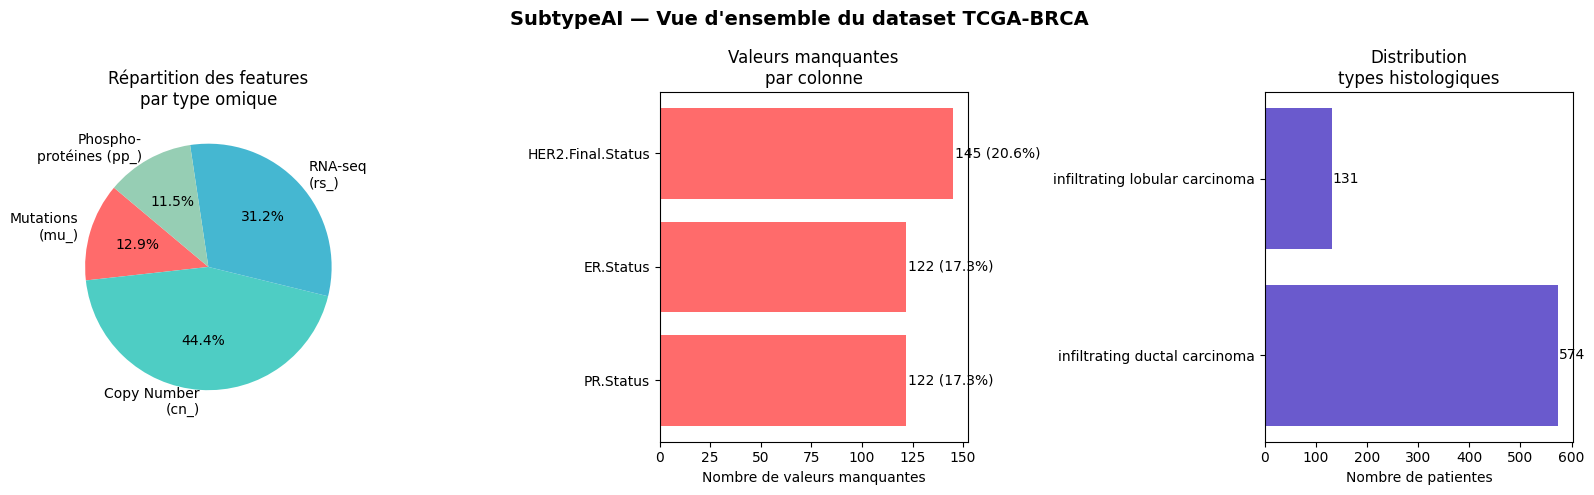

In [10]:
# VISUALISATION RÉCAPITULATIVE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('OncoPrint Vue d\'ensemble du dataset TCGA-BRCA',
             fontsize=14, fontweight='bold')

# Graphe 1 Features par type omique
labels = ['Mutations\n(mu_)', 'Copy Number\n(cn_)',
          'RNA-seq\n(rs_)', 'Phospho-\nprotéines (pp_)']
sizes  = [len(mu_cols), len(cn_cols), len(rs_cols), len(pp_cols)]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

axes[0].pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140)
axes[0].set_title('Répartition des features\npar type omique')

# Graphe 2 Valeurs manquantes
missing_plot = missing[missing > 0]
axes[1].barh(missing_plot.index, missing_plot.values, color='#FF6B6B')
axes[1].set_title('Valeurs manquantes\npar colonne')
axes[1].set_xlabel('Nombre de valeurs manquantes')
for i, v in enumerate(missing_plot.values):
    axes[1].text(v + 1, i, f'{v} ({v/705*100:.1f}%)', va='center')

# Graphe 3 Types histologiques
histo_counts = df['histological.type'].value_counts()
axes[2].barh(histo_counts.index, histo_counts.values, color='slateblue')
axes[2].set_title('Distribution\ntypes histologiques')
axes[2].set_xlabel('Nombre de patientes')
for i, v in enumerate(histo_counts.values):
    axes[2].text(v + 1, i, str(v), va='center')

plt.tight_layout()
plt.show()

In [11]:
# FICHE RÉCAPITULATIVE FINALE
print("=" * 60)
print("FICHE DATASET OncoPrint")
print("=" * 60)
print(f"""
NOM          : TCGA-BRCA Multi-Omics
SOURCE       : The Cancer Genome Atlas (NCI/NIH)
ACCÈS        : Kaggle (brca_data_w_subtypes.csv)

POPULATION   : {df.shape[0]} patientes atteintes de cancer du sein
               invasif (ductal et lobulaire)

FEATURES     : {df.shape[1]} au total
  - {len(mu_cols)} mutations somatiques       (binaires : 0/1)
  - {len(cn_cols)} variations copy number    (ordinal : -2 à 2)
  - {len(rs_cols)} gènes RNA-seq             (continu, log-normalisé)
  - {len(pp_cols)} phospho-protéines         (continu, centré-réduit)

VARIABLES
CLINIQUES    : vital.status, PR.Status, ER.Status,
               HER2.Final.Status, histological.type

QUALITÉ      : Excellent — {missing.sum()} valeurs manquantes ({missing.sum()/df.size*100:.3f}%)
               Uniquement sur statuts hormonaux cliniques
               0 doublon

TARGET       : Sous-type moléculaire (à construire — bloc 4)
               via ER / PR / HER2 Status
""")

FICHE DATASET SubtypeAI

NOM          : TCGA-BRCA Multi-Omics
SOURCE       : The Cancer Genome Atlas (NCI/NIH)
ACCÈS        : Kaggle (brca_data_w_subtypes.csv)

POPULATION   : 705 patientes atteintes de cancer du sein
               invasif (ductal et lobulaire)

FEATURES     : 1941 au total
  - 249 mutations somatiques       (binaires : 0/1)
  - 860 variations copy number    (ordinal : -2 à 2)
  - 604 gènes RNA-seq             (continu, log-normalisé)
  - 223 phospho-protéines         (continu, centré-réduit)

VARIABLES    
CLINIQUES    : vital.status, PR.Status, ER.Status,
               HER2.Final.Status, histological.type

QUALITÉ      : Excellent — 389 valeurs manquantes (0.028%)
               Uniquement sur statuts hormonaux cliniques
               0 doublon

TARGET       : Sous-type moléculaire (à construire — bloc 4)
               via ER / PR / HER2 Status



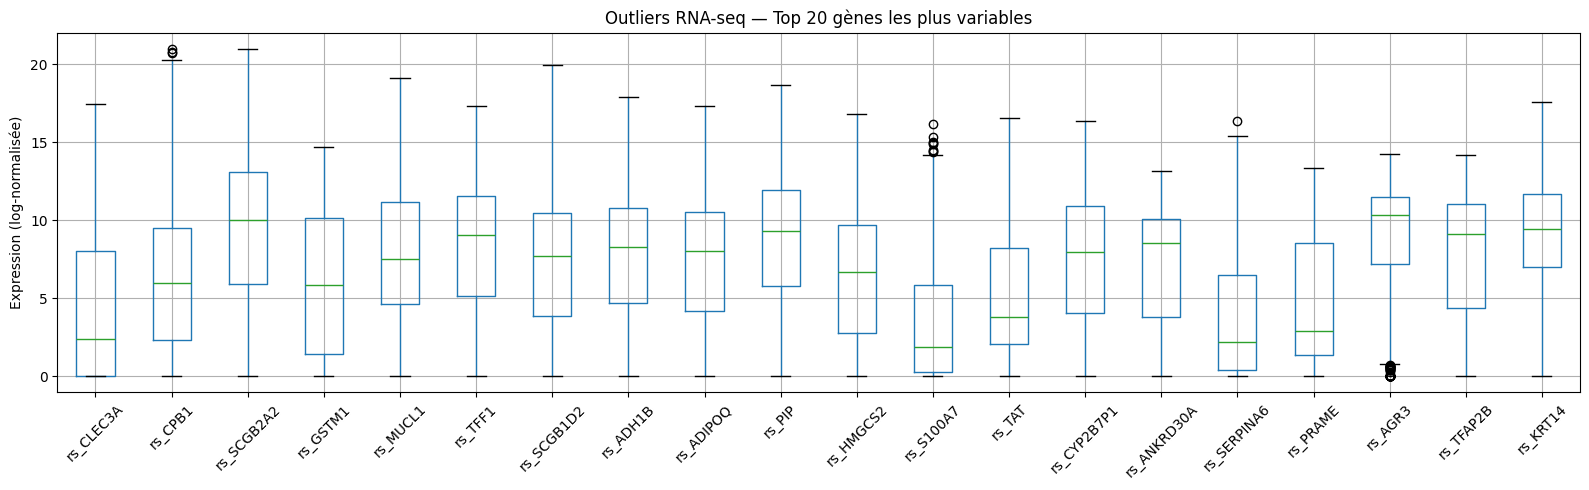

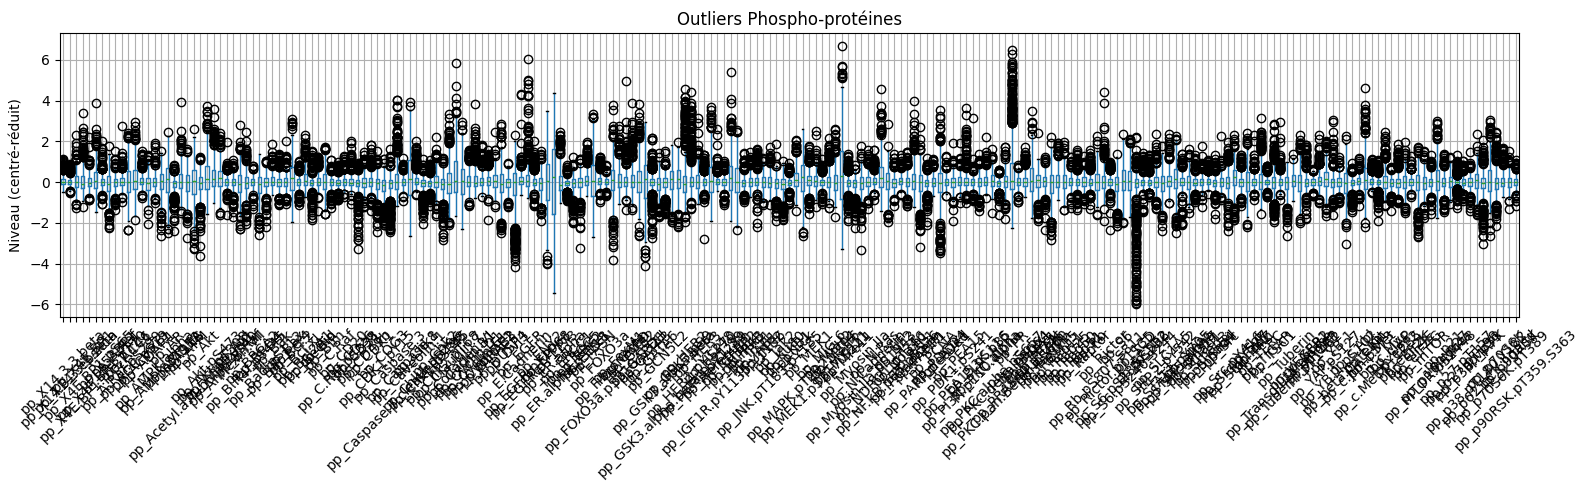

Valeurs RNA-seq avec z-score > 3 : 1518
Soit 0.36% des valeurs RNA-seq
Valeurs pp avec z-score > 3      : 1925
Soit 1.22% des valeurs pp

Copy number hors [-2, 2] : 0 valeurs
Mutations hors {0,1}      : 0 valeurs


In [12]:
# OUTLIERS & VALEURS ANORMALES

# 1. Boxplot RNA-seq, top 20 gènes les plus variables
rs_var = df[rs_cols].var().sort_values(ascending=False)
top20 = rs_var.head(20).index.tolist()

plt.figure(figsize=(16, 5))
df[top20].boxplot(rot=45)
plt.title('Outliers RNA-seq — Top 20 gènes les plus variables')
plt.ylabel('Expression (log-normalisée)')
plt.tight_layout()
plt.show()

# 2. Boxplot phospho-protéines
plt.figure(figsize=(16, 5))
df[pp_cols].boxplot(rot=45)
plt.title('Outliers Phospho-protéines')
plt.ylabel('Niveau (centré-réduit)')
plt.tight_layout()
plt.show()

# 3. Détecter les outliers extrêmes RNA-seq (z-score > 3)
from scipy import stats
z_scores = np.abs(stats.zscore(df[rs_cols].fillna(0)))
outliers_rs = (z_scores > 3).sum().sum()
print(f"Valeurs RNA-seq avec z-score > 3 : {outliers_rs}")
print(f"Soit {outliers_rs / (len(df) * len(rs_cols)) * 100:.2f}% des valeurs RNA-seq")

# 4. Idem phospho-protéines
z_scores_pp = np.abs(stats.zscore(df[pp_cols].fillna(0)))
outliers_pp = (z_scores_pp > 3).sum().sum()
print(f"Valeurs pp avec z-score > 3      : {outliers_pp}")
print(f"Soit {outliers_pp / (len(df) * len(pp_cols)) * 100:.2f}% des valeurs pp")

# 5. Copy number, vérifier les valeurs hors [-2, 2]
cn_anomalies = ((df[cn_cols] < -2) | (df[cn_cols] > 2)).sum().sum()
print(f"\nCopy number hors [-2, 2] : {cn_anomalies} valeurs")

# 6. Mutations, vérifier que tout est bien 0 ou 1
mu_anomalies = (~df[mu_cols].isin([0, 1])).sum().sum()
print(f"Mutations hors {{0,1}}      : {mu_anomalies} valeurs")

In [13]:
#4. CRÉER LA TARGET : SOUS-TYPE MOLÉCULAIRE
def classify_subtype(row):
    er  = row['ER.Status']
    pr  = row['PR.Status']
    her = row['HER2.Final.Status']

    if pd.isna(er) or pd.isna(pr) or pd.isna(her):
        return 'Unknown'

    er_pos  = er  == 'Positive'
    pr_pos  = pr  == 'Positive'
    her_pos = her == 'Positive'

    if (er_pos or pr_pos) and not her_pos:
        return 'Luminal A'
    elif (er_pos or pr_pos) and her_pos:
        return 'Luminal B / HER2+'
    elif not er_pos and not pr_pos and her_pos:
        return 'HER2-enriched'
    elif not er_pos and not pr_pos and not her_pos:
        return 'Triple Négatif'
    else:
        return 'Unknown'

df['subtype'] = df.apply(classify_subtype, axis=1)

print("=== DISTRIBUTION DES SOUS-TYPES ===")
print(df['subtype'].value_counts())
print("\nProportion :")
print(df['subtype'].value_counts(normalize=True).round(2))

=== DISTRIBUTION DES SOUS-TYPES ===
subtype
Luminal A            353
Unknown              145
Triple Négatif       121
Luminal B / HER2+     58
HER2-enriched         28
Name: count, dtype: int64

Proportion :
subtype
Luminal A            0.50
Unknown              0.21
Triple Négatif       0.17
Luminal B / HER2+    0.08
HER2-enriched        0.04
Name: proportion, dtype: float64


In [14]:
# PREPROCESSING SOUS-TYPES : traitement fin des Unknown

def classify_subtype_v2(row):
    er  = row['ER.Status']
    pr  = row['PR.Status']
    her = row['HER2.Final.Status']

    # Normaliser les valeurs ambiguës
    valeurs_manquantes = ['Not Performed', 'Performed but Not Available',
                          'Indeterminate', 'Not Available', float('nan')]

    er  = None if (pd.isna(er)  or er  in valeurs_manquantes) else er
    pr  = None if (pd.isna(pr)  or pr  in valeurs_manquantes) else pr
    # Equivocal HER2 = traité comme Negative (standard clinique)
    her = 'Negative' if her == 'Equivocal' else her
    her = None if (pd.isna(her) or her in valeurs_manquantes) else her

    if er is None or pr is None or her is None:
        return 'Unknown'

    er_pos  = er  == 'Positive'
    pr_pos  = pr  == 'Positive'
    her_pos = her == 'Positive'

    if (er_pos or pr_pos) and not her_pos:
        return 'Luminal A'
    elif (er_pos or pr_pos) and her_pos:
        return 'Luminal B / HER2+'
    elif not er_pos and not pr_pos and her_pos:
        return 'HER2-enriched'
    elif not er_pos and not pr_pos and not her_pos:
        return 'Triple Négatif'
    else:
        return 'Unknown'

df['subtype'] = df.apply(classify_subtype_v2, axis=1)

print("=== APRÈS TRAITEMENT FIN ===")
print(df['subtype'].value_counts())
print(f"\nUnknown restants : {(df['subtype'] == 'Unknown').sum()}")

# Supprimer les Unknown restants
df_clean = df[df['subtype'] != 'Unknown'].copy()
print(f"\n=== DATASET FINAL APRÈS SUPPRESSION UNKNOWN ===")
print(f"Patientes conservées : {len(df_clean)} / {len(df)}")
print(df_clean['subtype'].value_counts())
print(df_clean['subtype'].value_counts(normalize=True).round(2))

=== APRÈS TRAITEMENT FIN ===
subtype
Luminal A            343
Unknown              189
Triple Négatif        91
Luminal B / HER2+     57
HER2-enriched         25
Name: count, dtype: int64

Unknown restants : 189

=== DATASET FINAL APRÈS SUPPRESSION UNKNOWN ===
Patientes conservées : 516 / 705
subtype
Luminal A            343
Triple Négatif        91
Luminal B / HER2+     57
HER2-enriched         25
Name: count, dtype: int64
subtype
Luminal A            0.66
Triple Négatif       0.18
Luminal B / HER2+    0.11
HER2-enriched        0.05
Name: proportion, dtype: float64


In [15]:
# DIAGNOSTIC UNKNOWN

# Qui sont les 189 Unknown ?
unknown_df = df[df['subtype'] == 'Unknown'][['ER.Status', 'PR.Status', 'HER2.Final.Status']]

print("=== COMBINAISONS ER/PR/HER2 chez les Unknown ===")
print(unknown_df.value_counts(dropna=False).head(20))

print("\n=== ER.Status chez les Unknown ===")
print(unknown_df['ER.Status'].value_counts(dropna=False))

print("\n=== PR.Status chez les Unknown ===")
print(unknown_df['PR.Status'].value_counts(dropna=False))

print("\n=== HER2.Final.Status chez les Unknown ===")
print(unknown_df['HER2.Final.Status'].value_counts(dropna=False))

=== COMBINAISONS ER/PR/HER2 chez les Unknown ===
ER.Status                    PR.Status                    HER2.Final.Status
NaN                          NaN                          NaN                  122
Not Performed                Not Performed                Negative              25
Positive                     Positive                     NaN                   11
Negative                     Negative                     NaN                    7
Positive                     Positive                     Not Available          5
Performed but Not Available  Performed but Not Available  NaN                    3
Positive                     Indeterminate                Negative               3
Not Performed                Not Performed                Positive               2
Positive                     Negative                     Not Available          2
Performed but Not Available  Performed but Not Available  Negative               2
Positive                     Negative        

In [16]:
# RÉCUPÉRATION PARTIELLE DES UNKNOWN

def classify_subtype_v3(row):
    er  = row['ER.Status']
    pr  = row['PR.Status']
    her = row['HER2.Final.Status']

    # Normaliser
    mauvaises_valeurs = ['Not Performed', 'Performed but Not Available',
                         'Indeterminate', 'Not Available']

    er  = None if (pd.isna(er)  or er  in mauvaises_valeurs) else er
    pr  = None if (pd.isna(pr)  or pr  in mauvaises_valeurs) else pr
    her = 'Negative' if her == 'Equivocal' else her
    her = None if (pd.isna(her) or her in mauvaises_valeurs) else her

    er_pos  = er  == 'Positive'  if er  is not None else None
    pr_pos  = pr  == 'Positive'  if pr  is not None else None
    her_pos = her == 'Positive'  if her is not None else None

    # CAS RÉCUPÉRABLES — HER2 inconnu mais ER/PR connus
    if her_pos is None:
        # ER+ ou PR+ sans HER2 → Luminal A (hypothèse conservatrice)
        if er_pos or pr_pos:
            return 'Luminal A (imputed)'
        # ER- et PR- sans HER2 → inclassable
        if er_pos == False and pr_pos == False:
            return 'Unknown'

    # CAS STANDARD
    if er is None or pr is None or her is None:
        return 'Unknown'

    if (er_pos or pr_pos) and not her_pos:
        return 'Luminal A'
    elif (er_pos or pr_pos) and her_pos:
        return 'Luminal B / HER2+'
    elif not er_pos and not pr_pos and her_pos:
        return 'HER2-enriched'
    elif not er_pos and not pr_pos and not her_pos:
        return 'Triple Négatif'
    else:
        return 'Unknown'

df['subtype_v3'] = df.apply(classify_subtype_v3, axis=1)

print("=== RÉSULTAT V3 ===")
print(df['subtype_v3'].value_counts())

# Fusionner Luminal A et Luminal A (imputed)
df['subtype_v3'] = df['subtype_v3'].replace('Luminal A (imputed)', 'Luminal A')

# Dataset final
df_clean = df[df['subtype_v3'] != 'Unknown'].copy()
df_clean = df_clean.rename(columns={'subtype_v3': 'subtype_final'})

print(f"\n=== DATASET FINAL ===")
print(f"Patientes conservées : {len(df_clean)} / {len(df)}")
print(df_clean['subtype_final'].value_counts())
print(df_clean['subtype_final'].value_counts(normalize=True).round(2))

=== RÉSULTAT V3 ===
subtype_v3
Luminal A              343
Unknown                169
Triple Négatif          91
Luminal B / HER2+       57
HER2-enriched           25
Luminal A (imputed)     20
Name: count, dtype: int64

=== DATASET FINAL ===
Patientes conservées : 536 / 705
subtype_final
Luminal A            363
Triple Négatif        91
Luminal B / HER2+     57
HER2-enriched         25
Name: count, dtype: int64
subtype_final
Luminal A            0.68
Triple Négatif       0.17
Luminal B / HER2+    0.11
HER2-enriched        0.05
Name: proportion, dtype: float64


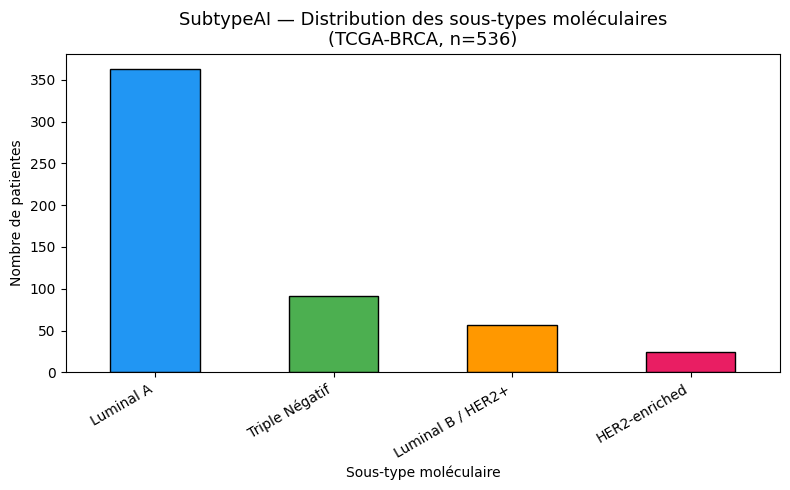

In [19]:
# 5. VISUALISATION SOUS-TYPES FINAL
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

plt.figure(figsize=(8, 5))
df_clean['subtype_final'].value_counts().plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)
plt.title('OncoPrint — Distribution des sous-types moléculaires\n(TCGA-BRCA, n=536)', fontsize=13)
plt.xlabel('Sous-type moléculaire')
plt.ylabel('Nombre de patientes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Mutations (mu_)         : 249 features
Copy Number (cn_)       : 860 features
RNA-seq (rs_)           : 604 features
Phospho-protéines (pp_) : 223 features


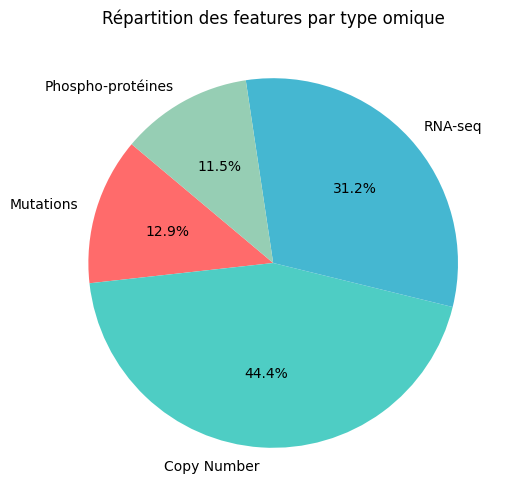

In [21]:
# 6. SÉPARER LES FEATURES PAR TYPE OMIQUE
mu_cols = [c for c in df.columns if c.startswith('mu_')]
cn_cols = [c for c in df.columns if c.startswith('cn_')]
rs_cols = [c for c in df.columns if c.startswith('rs_')]
pp_cols = [c for c in df.columns if c.startswith('pp_')]

print(f"Mutations (mu_)         : {len(mu_cols)} features")
print(f"Copy Number (cn_)       : {len(cn_cols)} features")
print(f"RNA-seq (rs_)           : {len(rs_cols)} features")
print(f"Phospho-protéines (pp_) : {len(pp_cols)} features")

# Camembert
plt.figure(figsize=(6, 6))
plt.pie(
    [len(mu_cols), len(cn_cols), len(rs_cols), len(pp_cols)],
    labels=['Mutations', 'Copy Number', 'RNA-seq', 'Phospho-protéines'],
    colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Répartition des features par type omique')
plt.show()

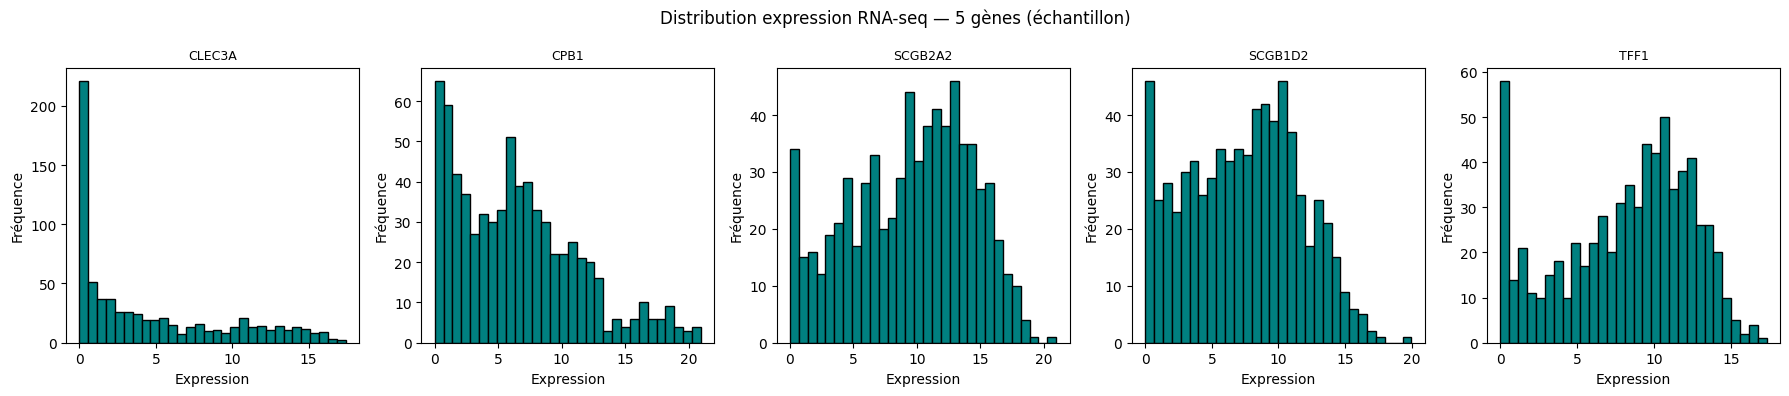

In [22]:
# 7. DISTRIBUTION EXPRESSION RNA-seq (5 gènes)
sample_genes = rs_cols[:5]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, gene in enumerate(sample_genes):
    axes[i].hist(df[gene].dropna(), bins=30, color='teal', edgecolor='black')
    axes[i].set_title(gene.replace('rs_', ''), fontsize=9)
    axes[i].set_xlabel('Expression')
    axes[i].set_ylabel('Fréquence')
plt.suptitle('Distribution expression RNA-seq — 5 gènes (échantillon)', fontsize=12)
plt.tight_layout()
plt.show()

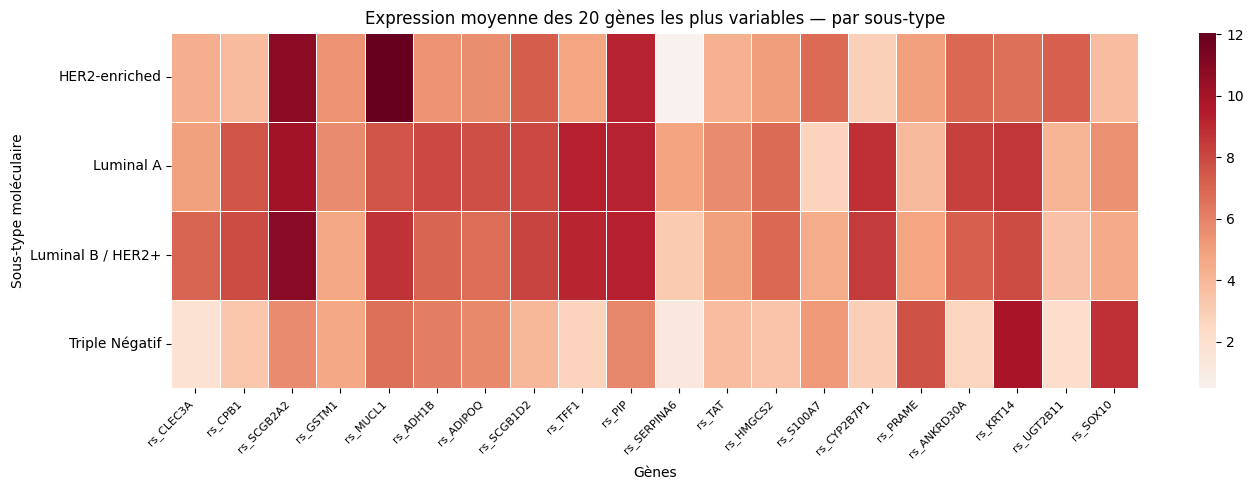

In [25]:
# 8. HEATMAP — EXPRESSION RNA-seq PAR SOUS-TYPE
rs_var = df_clean[rs_cols].var().sort_values(ascending=False)
top20_genes = rs_var.head(20).index.tolist()

heatmap_data = df_clean.groupby('subtype_final')[top20_genes].mean()

plt.figure(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    annot=False
)
plt.title('Expression moyenne des 20 gènes les plus variables — par sous-type', fontsize=12)
plt.xlabel('Gènes')
plt.ylabel('Sous-type moléculaire')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

=== TYPE HISTOLOGIQUE ===
histological.type
infiltrating ductal carcinoma     574
infiltrating lobular carcinoma    131
Name: count, dtype: int64


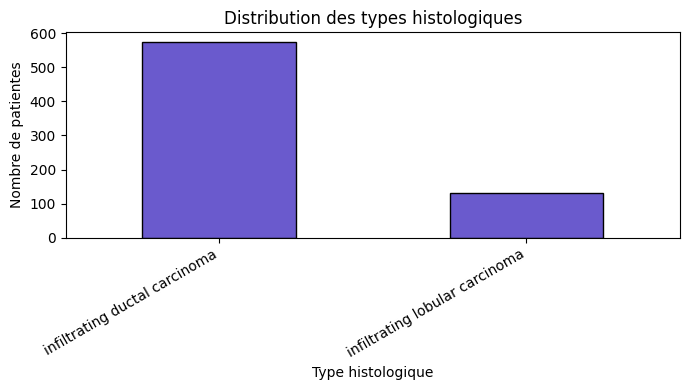

In [26]:
# 9. TYPE HISTOLOGIQUE

print("=== TYPE HISTOLOGIQUE ===")
print(df['histological.type'].value_counts())

plt.figure(figsize=(7, 4))
df['histological.type'].value_counts().plot(kind='bar', color='slateblue', edgecolor='black')
plt.title('Distribution des types histologiques')
plt.xlabel('Type histologique')
plt.ylabel('Nombre de patientes')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [31]:
# RÉSUMÉ EDA CORRIGÉ
print("=" * 50)
print("RÉSUMÉ EDA — OncoPrint")
print("=" * 50)
print(f"Patientes brutes         : {705}")
print(f"Patientes après nettoyage: {len(df_clean)}")
print(f"Features omiques         : 1936")
print(f"  (249 mu + 860 cn + 604 rs + 223 pp)")
print(f"Variables cliniques      : 5")
print(f"Valeurs manquantes       : 389 (0.028%)")
print(f"Sous-types créés         : {df_clean['subtype_final'].nunique()}")
print(f"\nDistribution finale (n={len(df_clean)}) :")
print(df_clean['subtype_final'].value_counts())
print(f"\nPatientes exclues (Unknown) : {705 - len(df_clean)} (24%)")
print("\n EDA terminée — prêt pour le preprocessing")

RÉSUMÉ EDA — SubtypeAI
Patientes brutes         : 705
Patientes après nettoyage: 536
Features omiques         : 1936
  (249 mu + 860 cn + 604 rs + 223 pp)
Variables cliniques      : 5
Valeurs manquantes       : 389 (0.028%)
Sous-types créés         : 4

Distribution finale (n=536) :
subtype_final
Luminal A            363
Triple Négatif        91
Luminal B / HER2+     57
HER2-enriched         25
Name: count, dtype: int64

Patientes exclues (Unknown) : 169 (24%)

 EDA terminée — prêt pour le preprocessing


In [34]:
# ============================================
# OncoPrint — 02_Preprocessing.ipynb
# Marine Deldicque — CDSD Jedha 2026
# ============================================

# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

print("Imports OK")

Imports OK


In [35]:
# 2. RÉCUPÉRER LE DATASET PROPRE
# (df_clean et toutes les variables sont déjà en mémoire depuis l'EDA)
# Si tu relances depuis zéro, recharge le CSV et relance les blocs EDA d'abord

print(f"Dataset de départ : {df_clean.shape}")
print(f"Target : subtype_final")
print(df_clean['subtype_final'].value_counts())

Dataset de départ : (536, 1943)
Target : subtype_final
subtype_final
Luminal A            363
Triple Négatif        91
Luminal B / HER2+     57
HER2-enriched         25
Name: count, dtype: int64


In [36]:
# 3. SÉLECTIONNER LES FEATURES

# On garde uniquement les features omiques — pas les colonnes cliniques
# qui ont servi à construire la target (éviter la fuite de données)
feature_cols = mu_cols + cn_cols + rs_cols + pp_cols

print(f"Features sélectionnées : {len(feature_cols)}")
print(f"  mu_ : {len(mu_cols)}")
print(f"  cn_ : {len(cn_cols)}")
print(f"  rs_ : {len(rs_cols)}")
print(f"  pp_ : {len(pp_cols)}")

X = df_clean[feature_cols].copy()
y = df_clean['subtype_final'].copy()

print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")

Features sélectionnées : 1936
  mu_ : 249
  cn_ : 860
  rs_ : 604
  pp_ : 223

X shape : (536, 1936)
y shape : (536,)


In [37]:
# 4. VÉRIFIER LES VALEURS MANQUANTES DANS X
missing_X = X.isnull().sum().sum()
print(f"Valeurs manquantes dans X : {missing_X}")

# Si manquants → imputation par médiane
if missing_X > 0:
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)
    print(f"Imputation médiane appliquée")
else:
    print(f"Aucun manquant — pas d'imputation nécessaire")

Valeurs manquantes dans X : 0
Aucun manquant — pas d'imputation nécessaire


In [38]:
# 5. ENCODAGE DE LA TARGET
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes encodées :")
for i, classe in enumerate(le.classes_):
    print(f"  {i} → {classe}")

Classes encodées :
  0 → HER2-enriched
  1 → Luminal A
  2 → Luminal B / HER2+
  3 → Triple Négatif


In [39]:
# 6. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # important : garder les proportions de classes
)

print(f"Train : {X_train.shape[0]} patientes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]} patientes ({X_test.shape[0]/len(X)*100:.1f}%)")

# Vérifier la distribution dans train et test
print("\nDistribution train :")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]} : {c}")

print("\nDistribution test :")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]} : {c}")

Train : 428 patientes (79.9%)
Test  : 108 patientes (20.1%)

Distribution train :
  HER2-enriched : 20
  Luminal A : 290
  Luminal B / HER2+ : 45
  Triple Négatif : 73

Distribution test :
  HER2-enriched : 5
  Luminal A : 73
  Luminal B / HER2+ : 12
  Triple Négatif : 18


In [40]:
# 7. NORMALISATION
# StandardScaler sur rs_ et pp_ uniquement
# mu_ (binaire 0/1) et cn_ (ordinal -2 à 2) ne nécessitent pas de scaling

# Indices des colonnes par type
mu_idx = [feature_cols.index(c) for c in mu_cols]
cn_idx = [feature_cols.index(c) for c in cn_cols]
rs_idx = [feature_cols.index(c) for c in rs_cols]
pp_idx = [feature_cols.index(c) for c in pp_cols]

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

# Scaler fitté UNIQUEMENT sur le train → appliqué sur train ET test
scaler = StandardScaler()
rs_pp_cols = rs_cols + pp_cols

X_train_scaled[rs_pp_cols] = scaler.fit_transform(X_train[rs_pp_cols])
X_test_scaled[rs_pp_cols]  = scaler.transform(X_test[rs_pp_cols])

print("StandardScaler appliqué sur rs_ et pp_")
print(f"Moyenne après scaling (train, rs_) : {X_train_scaled[rs_cols].mean().mean():.4f}")
print(f"Std après scaling (train, rs_)     : {X_train_scaled[rs_cols].std().mean():.4f}")

StandardScaler appliqué sur rs_ et pp_
Moyenne après scaling (train, rs_) : 0.0000
Std après scaling (train, rs_)     : 1.0012


In [41]:
# 8. GESTION DU DÉSÉQUILIBRE / SMOTE
# SMOTE = Synthetic Minority Oversampling Technique
# Génère des exemples synthétiques pour les classes minoritaires
# S'applique UNIQUEMENT sur le train, jamais sur le test

print("Avant SMOTE :")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]} : {c}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

print("\nAprès SMOTE :")
unique, counts = np.unique(y_train_resampled, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]} : {c}")

print(f"\nTrain avant SMOTE : {X_train_scaled.shape[0]} patientes")
print(f"Train après SMOTE : {X_train_resampled.shape[0]} patientes")

Avant SMOTE :
  HER2-enriched : 20
  Luminal A : 290
  Luminal B / HER2+ : 45
  Triple Négatif : 73

Après SMOTE :
  HER2-enriched : 290
  Luminal A : 290
  Luminal B / HER2+ : 290
  Triple Négatif : 290

Train avant SMOTE : 428 patientes
Train après SMOTE : 1160 patientes


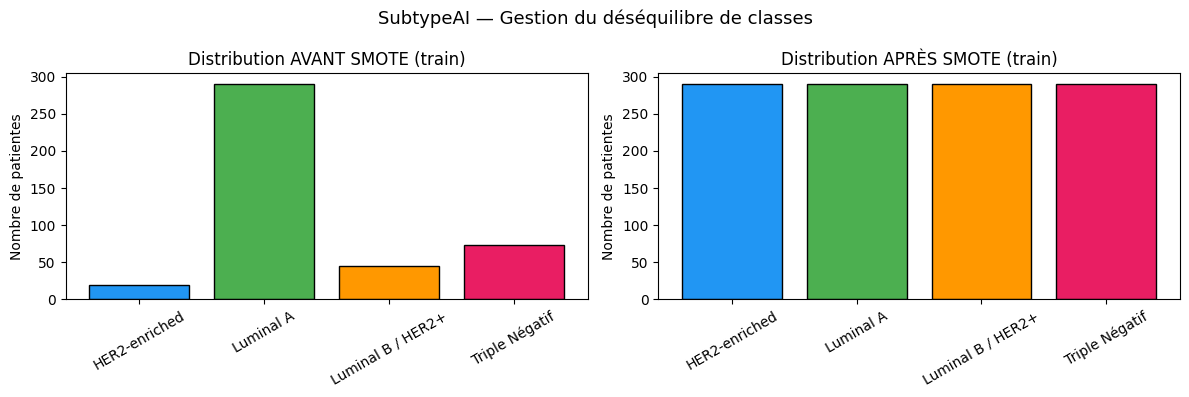

In [42]:
# 9. VISUALISATION AVANT / APRÈS SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Avant
classes_avant = [le.classes_[u] for u in np.unique(y_train)]
counts_avant  = [np.sum(y_train == u) for u in np.unique(y_train)]
axes[0].bar(classes_avant, counts_avant,
            color=['#2196F3','#4CAF50','#FF9800','#E91E63'],
            edgecolor='black')
axes[0].set_title('Distribution AVANT SMOTE (train)')
axes[0].set_ylabel('Nombre de patientes')
axes[0].tick_params(axis='x', rotation=30)

# Après
classes_apres = [le.classes_[u] for u in np.unique(y_train_resampled)]
counts_apres  = [np.sum(y_train_resampled == u) for u in np.unique(y_train_resampled)]
axes[1].bar(classes_apres, counts_apres,
            color=['#2196F3','#4CAF50','#FF9800','#E91E63'],
            edgecolor='black')
axes[1].set_title('Distribution APRÈS SMOTE (train)')
axes[1].set_ylabel('Nombre de patientes')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('OncoPrint — Gestion du déséquilibre de classes', fontsize=13)
plt.tight_layout()
plt.show()

In [43]:
# 10. RÉDUCTION DE DIMENSION sélection de features
# 1936 features c'est beaucoup on garde les plus informatives
# Variance threshold : supprimer les features quasi-constantes

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_resampled)
X_test_selected  = selector.transform(X_test_scaled)

n_removed = X_train_resampled.shape[1] - X_train_selected.shape[1]
print(f"Features initiales  : {X_train_resampled.shape[1]}")
print(f"Features supprimées : {n_removed} (variance < 0.01)")
print(f"Features conservées : {X_train_selected.shape[1]}")

Features initiales  : 1936
Features supprimées : 128 (variance < 0.01)
Features conservées : 1808


In [44]:
# 11. RÉSUMÉ PREPROCESSING
print("=" * 50)
print("RÉSUMÉ PREPROCESSING — OncoPrint")
print("=" * 50)
print(f"Dataset initial       : {df_clean.shape[0]} patientes")
print(f"Features omiques      : {len(feature_cols)}")
print(f"Features après sélection : {X_train_selected.shape[1]}")
print(f"Train (avant SMOTE)   : {X_train_scaled.shape[0]} patientes")
print(f"Train (après SMOTE)   : {X_train_resampled.shape[0]} patientes")
print(f"Test                  : {X_test_scaled.shape[0]} patientes")
print(f"\nÉtapes appliquées :")
print(f"Exclusion colonnes cliniques (fuite de données)")
print(f"Encodage LabelEncoder sur la target")
print(f"Train/Test split stratifié (80/20)")
print(f"StandardScaler sur rs_ et pp_")
print(f"SMOTE sur le train uniquement")
print(f"VarianceThreshold (suppression features quasi-constantes)")
print(f"\n Preprocessing terminé — prêt pour le ML")

RÉSUMÉ PREPROCESSING — SubtypeAI
Dataset initial       : 536 patientes
Features omiques      : 1936
Features après sélection : 1808
Train (avant SMOTE)   : 428 patientes
Train (après SMOTE)   : 1160 patientes
Test                  : 108 patientes

Étapes appliquées :
Exclusion colonnes cliniques (fuite de données)
Encodage LabelEncoder sur la target
Train/Test split stratifié (80/20)
StandardScaler sur rs_ et pp_
SMOTE sur le train uniquement
VarianceThreshold (suppression features quasi-constantes)

 Preprocessing terminé — prêt pour le ML


In [45]:
# ============================================
# OncoPrint — 04_Supervised_ML.ipynb
# Marine Deldicque — CDSD Jedha 2026
# ============================================

# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score,
                             RocCurveDisplay)
from sklearn.model_selection import cross_val_score, GridSearchCV
import xgboost as XGBClassifier

print("Imports OK")

Imports OK


In [46]:
# 2. VÉRIFICATION DES DONNÉES
print(f"X_train_resampled : {X_train_resampled.shape}")
print(f"X_test_scaled     : {X_test_scaled.shape}")
print(f"y_train_resampled : {y_train_resampled.shape}")
print(f"y_test            : {y_test.shape}")
print(f"\nClasses : {le.classes_}")

X_train_resampled : (1160, 1936)
X_test_scaled     : (108, 1936)
y_train_resampled : (1160,)
y_test            : (108,)

Classes : ['HER2-enriched' 'Luminal A' 'Luminal B / HER2+' 'Triple Négatif']


In [47]:
# 3. BASELINE — MODÈLE DUMMY
# On établit un score minimal à battre
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_resampled, y_train_resampled)
dummy_score = dummy.score(X_test_scaled, y_test)
print(f"Baseline (most frequent) : {dummy_score:.3f}")
print(f"→ Tout modèle sérieux doit dépasser {dummy_score:.1%}")

Baseline (most frequent) : 0.046
→ Tout modèle sérieux doit dépasser 4.6%


In [48]:
# 4. RANDOM FOREST BASELINE
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)

print("=== RANDOM FOREST — RÉSULTATS ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"F1 macro  : {f1_score(y_test, y_pred_rf, average='macro'):.3f}")
print(f"F1 weighted: {f1_score(y_test, y_pred_rf, average='weighted'):.3f}")
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

=== RANDOM FOREST — RÉSULTATS ===
Accuracy  : 0.806
F1 macro  : 0.692
F1 weighted: 0.782

Rapport détaillé :
                   precision    recall  f1-score   support

    HER2-enriched       0.83      1.00      0.91         5
        Luminal A       0.85      0.90      0.87        73
Luminal B / HER2+       0.67      0.17      0.27        12
   Triple Négatif       0.67      0.78      0.72        18

         accuracy                           0.81       108
        macro avg       0.75      0.71      0.69       108
     weighted avg       0.80      0.81      0.78       108



In [49]:
# 5. XGBOOST
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1
)
xgb.fit(X_train_resampled, y_train_resampled)
y_pred_xgb = xgb.predict(X_test_scaled)

print("=== XGBOOST — RÉSULTATS ===")
print(f"Accuracy   : {accuracy_score(y_test, y_pred_xgb):.3f}")
print(f"F1 macro   : {f1_score(y_test, y_pred_xgb, average='macro'):.3f}")
print(f"F1 weighted: {f1_score(y_test, y_pred_xgb, average='weighted'):.3f}")
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:43:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBOOST — RÉSULTATS ===
Accuracy   : 0.843
F1 macro   : 0.762
F1 weighted: 0.836

Rapport détaillé :
                   precision    recall  f1-score   support

    HER2-enriched       0.71      1.00      0.83         5
        Luminal A       0.89      0.90      0.90        73
Luminal B / HER2+       0.71      0.42      0.53        12
   Triple Négatif       0.75      0.83      0.79        18

         accuracy                           0.84       108
        macro avg       0.77      0.79      0.76       108
     weighted avg       0.84      0.84      0.84       108



In [50]:
# 6. RÉGRESSION LOGISTIQUE
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    multi_class='multinomial'
)
lr.fit(X_train_resampled, y_train_resampled)
y_pred_lr = lr.predict(X_test_scaled)

print("=== RÉGRESSION LOGISTIQUE — RÉSULTATS ===")
print(f"Accuracy   : {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"F1 macro   : {f1_score(y_test, y_pred_lr, average='macro'):.3f}")
print(f"F1 weighted: {f1_score(y_test, y_pred_lr, average='weighted'):.3f}")
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== RÉGRESSION LOGISTIQUE — RÉSULTATS ===
Accuracy   : 0.769
F1 macro   : 0.517
F1 weighted: 0.760

Rapport détaillé :
                   precision    recall  f1-score   support

    HER2-enriched       0.00      0.00      0.00         5
        Luminal A       0.88      0.86      0.87        73
Luminal B / HER2+       0.50      0.50      0.50        12
   Triple Négatif       0.64      0.78      0.70        18

         accuracy                           0.77       108
        macro avg       0.50      0.54      0.52       108
     weighted avg       0.75      0.77      0.76       108



               Modèle  Accuracy  F1 Macro
              XGBoost  0.842593  0.761770
        Random Forest  0.805556  0.691970
Régression Logistique  0.768519  0.517241
     Dummy (baseline)  0.046296  0.022124


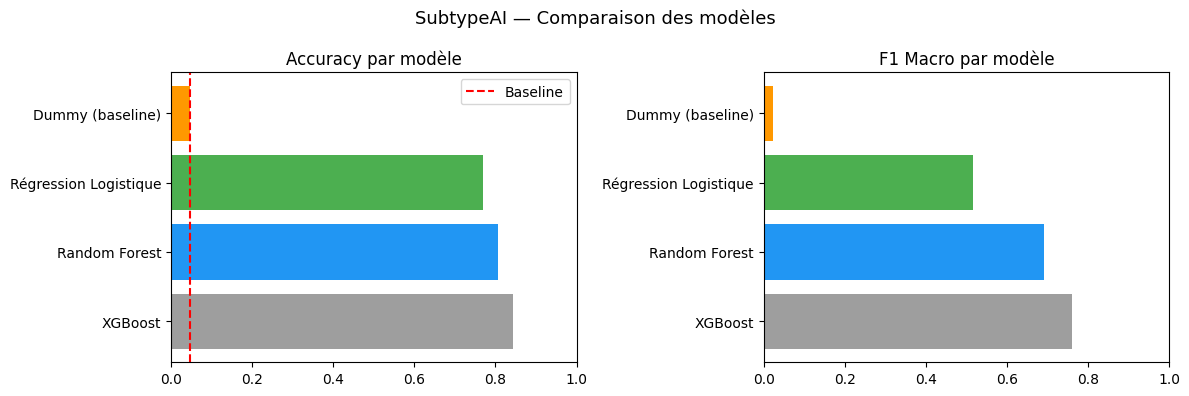

In [51]:
# 7. COMPARAISON DES MODÈLES
resultats = pd.DataFrame({
    'Modèle': ['Dummy (baseline)', 'Random Forest', 'XGBoost', 'Régression Logistique'],
    'Accuracy': [
        accuracy_score(y_test, dummy.predict(X_test_scaled)),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lr)
    ],
    'F1 Macro': [
        f1_score(y_test, dummy.predict(X_test_scaled), average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_xgb, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro')
    ]
}).sort_values('F1 Macro', ascending=False)

print(resultats.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(resultats['Modèle'], resultats['Accuracy'],
             color=['#9E9E9E','#2196F3','#4CAF50','#FF9800'])
axes[0].set_title('Accuracy par modèle')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=dummy_score, color='red', linestyle='--', label='Baseline')
axes[0].legend()

axes[1].barh(resultats['Modèle'], resultats['F1 Macro'],
             color=['#9E9E9E','#2196F3','#4CAF50','#FF9800'])
axes[1].set_title('F1 Macro par modèle')
axes[1].set_xlim(0, 1)

plt.suptitle('OncoPrint — Comparaison des modèles', fontsize=13)
plt.tight_layout()
plt.show()

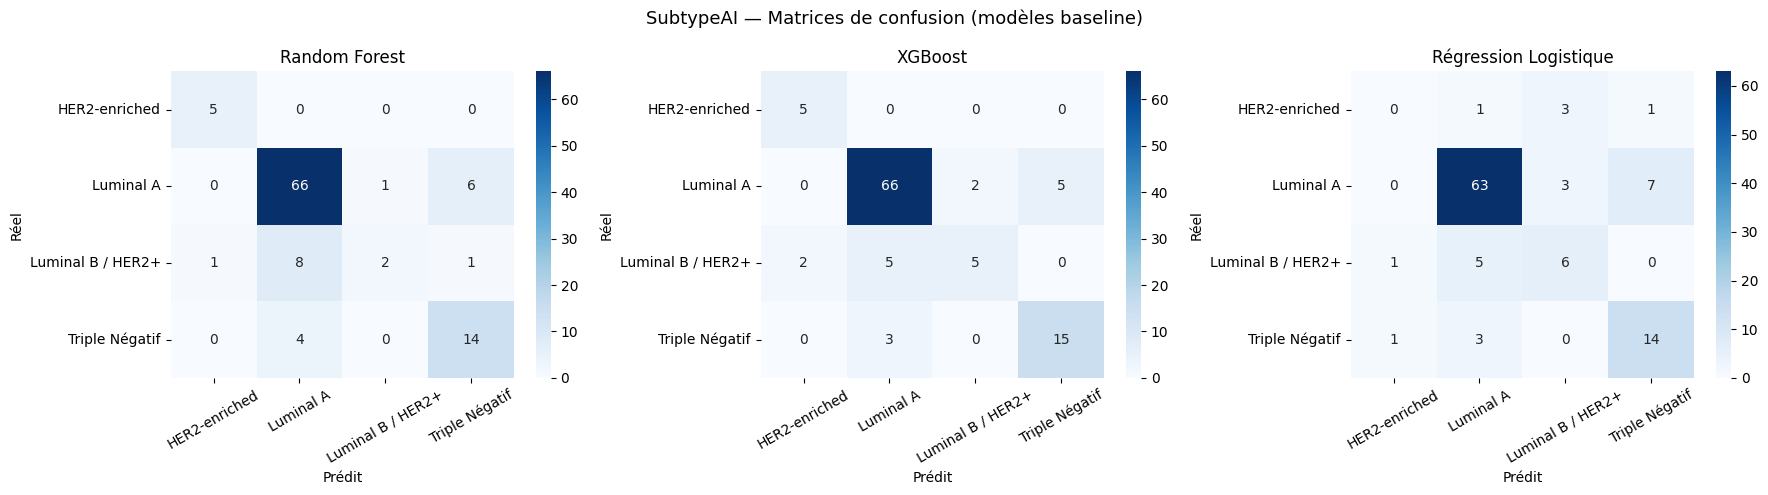

In [52]:
# 8. MATRICES DE CONFUSION — BASELINE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (y_pred, titre) in zip(axes, [
    (y_pred_rf,  'Random Forest'),
    (y_pred_xgb, 'XGBoost'),
    (y_pred_lr,  'Régression Logistique')
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                ax=ax)
    ax.set_title(f'{titre}')
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('OncoPrint — Matrices de confusion (modèles baseline)', fontsize=13)
plt.tight_layout()
plt.show()

In [53]:
# 9. VALIDATION CROISÉE — RF ET XGB BASELINE
cv_rf = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42,
                           class_weight='balanced', n_jobs=-1),
    X_train_resampled, y_train_resampled,
    cv=5, scoring='f1_macro', n_jobs=-1
)

cv_xgb = cross_val_score(
    XGBClassifier(n_estimators=100, random_state=42,
                  eval_metric='mlogloss', n_jobs=-1),
    X_train_resampled, y_train_resampled,
    cv=5, scoring='f1_macro', n_jobs=-1
)

print("=== VALIDATION CROISÉE 5-FOLD ===")
print(f"\nRandom Forest :")
print(f"  F1 par fold : {cv_rf.round(3)}")
print(f"  Moyenne     : {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")

print(f"\nXGBoost :")
print(f"  F1 par fold : {cv_xgb.round(3)}")
print(f"  Moyenne     : {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")

=== VALIDATION CROISÉE 5-FOLD ===

Random Forest :
  F1 par fold : [0.966 0.991 0.974 0.987 0.991]
  Moyenne     : 0.982 ± 0.010

XGBoost :
  F1 par fold : [0.957 0.978 0.956 0.969 0.991]
  Moyenne     : 0.970 ± 0.013


In [55]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold

# 9 CORRIGÉ — CV SANS DATA LEAKAGE

# Pipeline qui applique SMOTE uniquement sur le train à chaque fold
pipeline_rf = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42,
                                   class_weight='balanced', n_jobs=-1))
])

pipeline_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', XGBClassifier(n_estimators=100, random_state=42,
                          eval_metric='mlogloss', n_jobs=-1))
])

# On utilise X_train_scaled (AVANT SMOTE) et y_train (non rééchantillonné)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rf_correct = cross_val_score(
    pipeline_rf,
    X_train_scaled, y_train,  # ← données originales sans SMOTE
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

cv_xgb_correct = cross_val_score(
    pipeline_xgb,
    X_train_scaled, y_train,  # ← données originales sans SMOTE
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print("=== VALIDATION CROISÉE CORRIGÉE (sans data leakage) ===")
print(f"\nRandom Forest :")
print(f"  F1 par fold : {cv_rf_correct.round(3)}")
print(f"  Moyenne     : {cv_rf_correct.mean():.3f} ± {cv_rf_correct.std():.3f}")

print(f"\nXGBoost :")
print(f"  F1 par fold : {cv_xgb_correct.round(3)}")
print(f"  Moyenne     : {cv_xgb_correct.mean():.3f} ± {cv_xgb_correct.std():.3f}")

print(f"\nComparaison avant/après correction :")
print(f"  RF  avant : 0.982 → après : {cv_rf_correct.mean():.3f}")
print(f"  XGB avant : 0.970 → après : {cv_xgb_correct.mean():.3f}")

=== VALIDATION CROISÉE CORRIGÉE (sans data leakage) ===

Random Forest :
  F1 par fold : [0.635 0.622 0.723 0.634 0.727]
  Moyenne     : 0.668 ± 0.047

XGBoost :
  F1 par fold : [0.708 0.7   0.758 0.721 0.686]
  Moyenne     : 0.715 ± 0.025

Comparaison avant/après correction :
  RF  avant : 0.982 → après : 0.668
  XGB avant : 0.970 → après : 0.715


In [56]:
# 10a. OPTIMISATION — RANDOM FOREST
print("⏳ GridSearch Random Forest en cours...")

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
gs_rf.fit(X_train_resampled, y_train_resampled)

best_rf = gs_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_scaled)

print(f"\nMeilleurs paramètres RF : {gs_rf.best_params_}")
print(f"Meilleur F1 Macro (CV)  : {gs_rf.best_score_:.3f}")
print(f"\n=== RANDOM FOREST OPTIMISÉ — TEST ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best_rf):.3f}")
print(f"F1 Macro : {f1_score(y_test, y_pred_best_rf, average='macro'):.3f}")
print(classification_report(y_test, y_pred_best_rf, target_names=le.classes_))

⏳ GridSearch Random Forest en cours...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Meilleurs paramètres RF : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Meilleur F1 Macro (CV)  : 0.975

=== RANDOM FOREST OPTIMISÉ — TEST ===
Accuracy : 0.824
F1 Macro : 0.727
                   precision    recall  f1-score   support

    HER2-enriched       0.83      1.00      0.91         5
        Luminal A       0.86      0.92      0.89        73
Luminal B / HER2+       0.75      0.25      0.38        12
   Triple Négatif       0.70      0.78      0.74        18

         accuracy                           0.82       108
        macro avg       0.79      0.74      0.73       108
     weighted avg       0.82      0.82      0.81       108



In [57]:
# 10b. OPTIMISATION — XGBOOST
print("⏳ GridSearch XGBoost en cours...")

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.05, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

gs_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1),
    param_grid_xgb,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
gs_xgb.fit(X_train_resampled, y_train_resampled)

best_xgb = gs_xgb.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test_scaled)

print(f"\nMeilleurs paramètres XGB : {gs_xgb.best_params_}")
print(f"Meilleur F1 Macro (CV)   : {gs_xgb.best_score_:.3f}")
print(f"\n=== XGBOOST OPTIMISÉ — TEST ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_best_xgb):.3f}")
print(f"F1 Macro : {f1_score(y_test, y_pred_best_xgb, average='macro'):.3f}")
print(classification_report(y_test, y_pred_best_xgb, target_names=le.classes_))

⏳ GridSearch XGBoost en cours...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Meilleurs paramètres XGB : {'learning_rate': 0.3, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Meilleur F1 Macro (CV)   : 0.971

=== XGBOOST OPTIMISÉ — TEST ===
Accuracy : 0.843
F1 Macro : 0.763
                   precision    recall  f1-score   support

    HER2-enriched       0.71      1.00      0.83         5
        Luminal A       0.90      0.89      0.90        73
Luminal B / HER2+       0.62      0.42      0.50        12
   Triple Négatif       0.76      0.89      0.82        18

         accuracy                           0.84       108
        macro avg       0.75      0.80      0.76       108
     weighted avg       0.84      0.84      0.84       108



        Modèle  Accuracy  F1 Macro
  XGB optimisé  0.842593  0.762599
  XGB baseline  0.842593  0.761770
   RF optimisé  0.824074  0.727088
   RF baseline  0.805556  0.691970
Dummy baseline  0.046296  0.022124


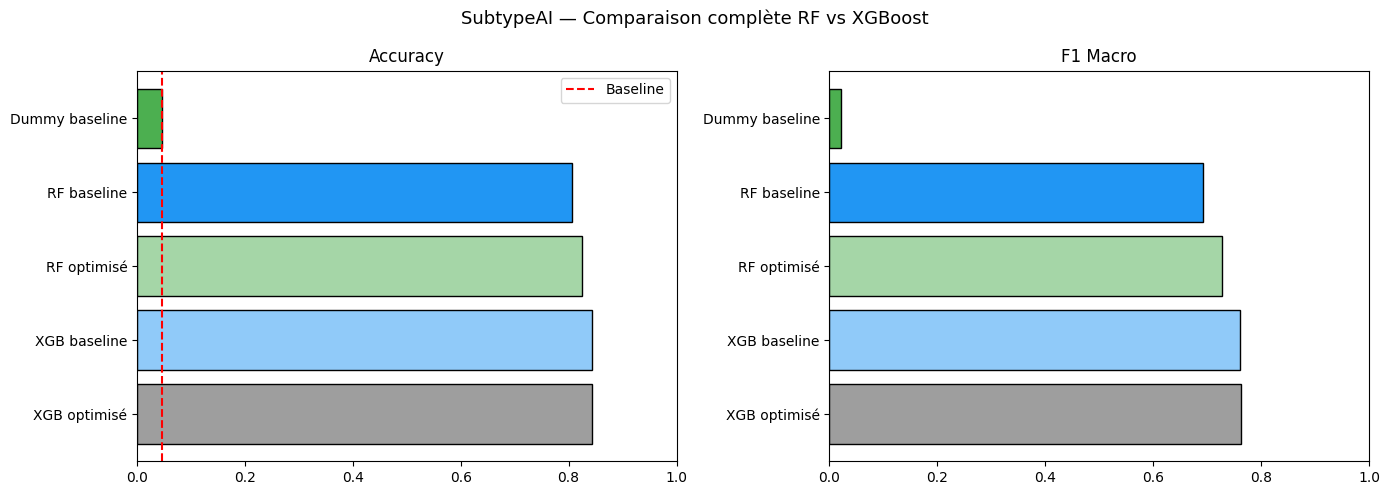

In [58]:
# 11. COMPARAISON FINALE RF vs XGB optimisés

comparaison = pd.DataFrame({
'Modèle': [
'Dummy baseline',
'RF baseline',
'XGB baseline',
'RF optimisé',
'XGB optimisé'
],
'Accuracy': [
accuracy_score(y_test, dummy.predict(X_test_scaled)),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_xgb),
accuracy_score(y_test, y_pred_best_rf),
accuracy_score(y_test, y_pred_best_xgb)
],
'F1 Macro': [
f1_score(y_test, dummy.predict(X_test_scaled), average='macro'),
f1_score(y_test, y_pred_rf, average='macro'),
f1_score(y_test, y_pred_xgb, average='macro'),
f1_score(y_test, y_pred_best_rf, average='macro'),
f1_score(y_test, y_pred_best_xgb, average='macro')
]
}).sort_values('F1 Macro', ascending=False)

print(comparaison.to_string(index=False))

# Visualisation

colors = ['#9E9E9E','#90CAF9','#A5D6A7','#2196F3','#4CAF50']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(comparaison['Modèle'], comparaison['Accuracy'],
color=colors, edgecolor='black')
axes[0].set_title('Accuracy')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=dummy_score, color='red', linestyle='--', label='Baseline')
axes[0].legend()

axes[1].barh(comparaison['Modèle'], comparaison['F1 Macro'],
color=colors, edgecolor='black')
axes[1].set_title('F1 Macro')
axes[1].set_xlim(0, 1)

plt.suptitle('OncoPrint — Comparaison complète RF vs XGBoost', fontsize=13)
plt.tight_layout()
plt.show()

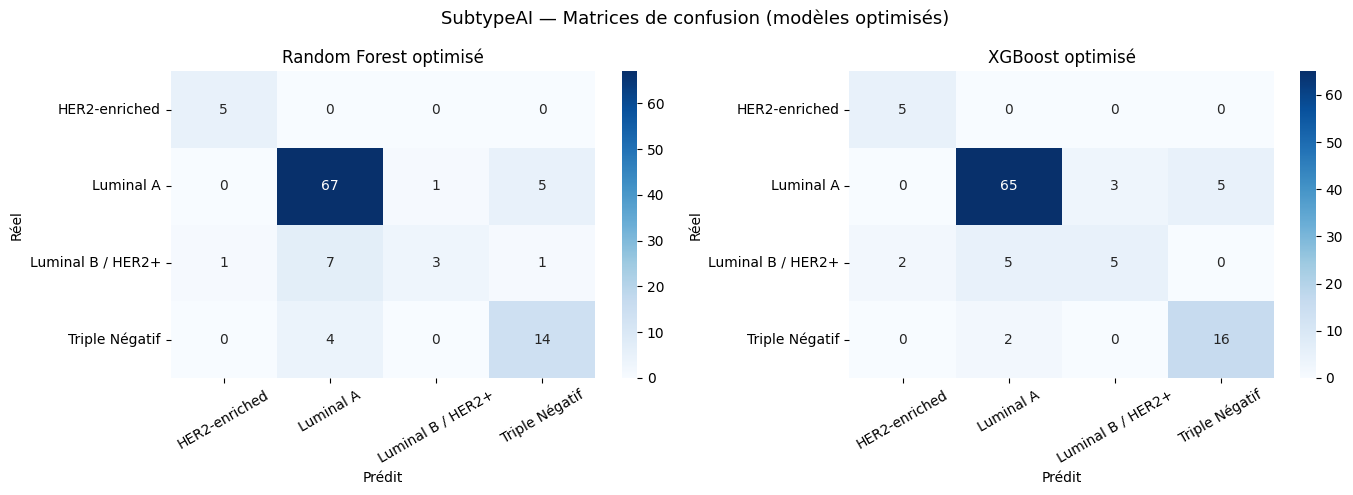

In [60]:
# 12. MATRICES DE CONFUSION — MODÈLES OPTIMISÉS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_pred, titre) in zip(axes, [
    (y_pred_best_rf,  'Random Forest optimisé'),
    (y_pred_best_xgb, 'XGBoost optimisé')
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_,
                ax=ax)
    ax.set_title(titre)
    ax.set_xlabel('Prédit')
    ax.set_ylabel('Réel')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('OncoPrint — Matrices de confusion (modèles optimisés)', fontsize=13)
plt.tight_layout()
plt.show()

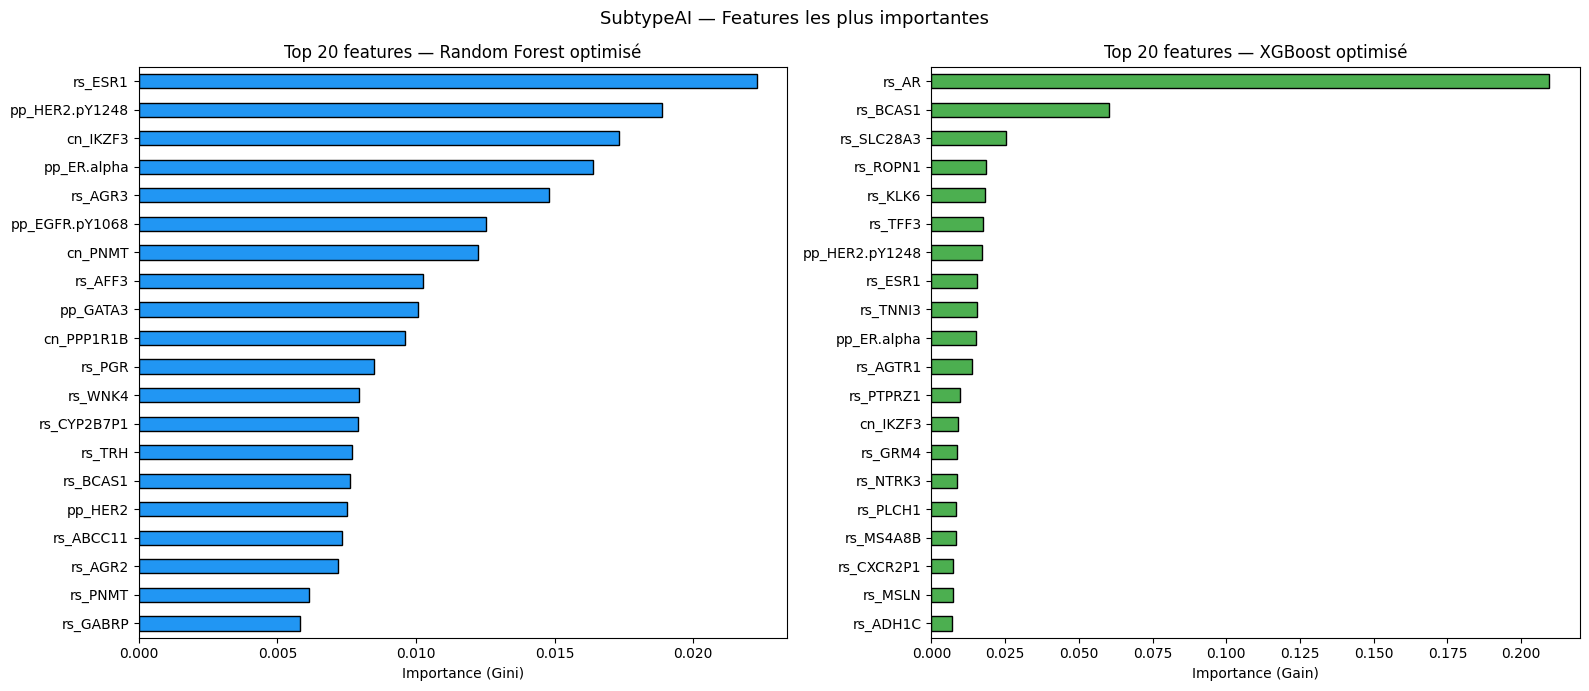


Features dans le top 10 des DEUX modèles (3) :
  pp_ER.alpha
  rs_ESR1
  pp_HER2.pY1248


In [61]:
# 13. FEATURE IMPORTANCE — LES DEUX MODÈLES

# Random Forest
importances_rf = pd.Series(
    best_rf.feature_importances_,
    index=feature_cols[:len(best_rf.feature_importances_)]
).sort_values(ascending=False).head(20)

# XGBoost
importances_xgb = pd.Series(
    best_xgb.feature_importances_,
    index=feature_cols[:len(best_xgb.feature_importances_)]
).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

importances_rf.plot(kind='barh', ax=axes[0],
                    color='#2196F3', edgecolor='black')
axes[0].set_title('Top 20 features — Random Forest optimisé')
axes[0].set_xlabel('Importance (Gini)')
axes[0].invert_yaxis()

importances_xgb.plot(kind='barh', ax=axes[1],
                     color='#4CAF50', edgecolor='black')
axes[1].set_title('Top 20 features — XGBoost optimisé')
axes[1].set_xlabel('Importance (Gain)')
axes[1].invert_yaxis()

plt.suptitle('OncoPrint — Features les plus importantes', fontsize=13)
plt.tight_layout()
plt.show()

# Top 10 communs aux deux modèles
top10_rf  = set(importances_rf.head(10).index)
top10_xgb = set(importances_xgb.head(10).index)
communs   = top10_rf & top10_xgb

print(f"\nFeatures dans le top 10 des DEUX modèles ({len(communs)}) :")
for f in communs:
    print(f"  {f}")

In [62]:
# 14. RÉSUMÉ FINAL

# Choisir le meilleur modèle
f1_rf_opt  = f1_score(y_test, y_pred_best_rf,  average='macro')
f1_xgb_opt = f1_score(y_test, y_pred_best_xgb, average='macro')
meilleur   = "XGBoost optimisé" if f1_xgb_opt > f1_rf_opt else "Random Forest optimisé"

print("=" * 55)
print("RÉSUMÉ SUPERVISED ML — OncoPrint")
print("=" * 55)
print(f"\nBaseline dummy         : {dummy_score:.3f}")
print(f"RF baseline            : {accuracy_score(y_test, y_pred_rf):.3f} (F1: {f1_score(y_test, y_pred_rf, average='macro'):.3f})")
print(f"XGB baseline           : {accuracy_score(y_test, y_pred_xgb):.3f} (F1: {f1_score(y_test, y_pred_xgb, average='macro'):.3f})")
print(f"RF optimisé            : {accuracy_score(y_test, y_pred_best_rf):.3f} (F1: {f1_rf_opt:.3f})")
print(f"XGB optimisé           : {accuracy_score(y_test, y_pred_best_xgb):.3f} (F1: {f1_xgb_opt:.3f})")
print(f"\n Meilleur modèle     : {meilleur}")
print(f"\nValidation croisée RF  : {cv_rf.mean():.3f} ± {cv_rf.std():.3f}")
print(f"Validation croisée XGB : {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}")
print(f"\n Supervised ML terminé — prêt pour l'unsupervised")

RÉSUMÉ SUPERVISED ML — SubtypeAI

Baseline dummy         : 0.046
RF baseline            : 0.806 (F1: 0.692)
XGB baseline           : 0.843 (F1: 0.762)
RF optimisé            : 0.824 (F1: 0.727)
XGB optimisé           : 0.843 (F1: 0.763)

 Meilleur modèle     : XGBoost optimisé

Validation croisée RF  : 0.982 ± 0.010
Validation croisée XGB : 0.970 ± 0.013

 Supervised ML terminé — prêt pour l'unsupervised


In [63]:
# ============================================
# OncoPrint — 03_Unsupervised_ML.ipynb
# Marine Deldicque — CDSD Jedha 2026
# ============================================

# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

print("Imports OK")

Imports OK


In [64]:
# 2. VÉRIFICATION DONNÉES
print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"y_train        : {y_train.shape}")
print(f"Classes        : {le.classes_}")

X_train_scaled : (428, 1936)
y_train        : (428,)
Classes        : ['HER2-enriched' 'Luminal A' 'Luminal B / HER2+' 'Triple Négatif']


Composantes pour 80% variance : 98
Composantes pour 90% variance : 175
Composantes pour 95% variance : 245


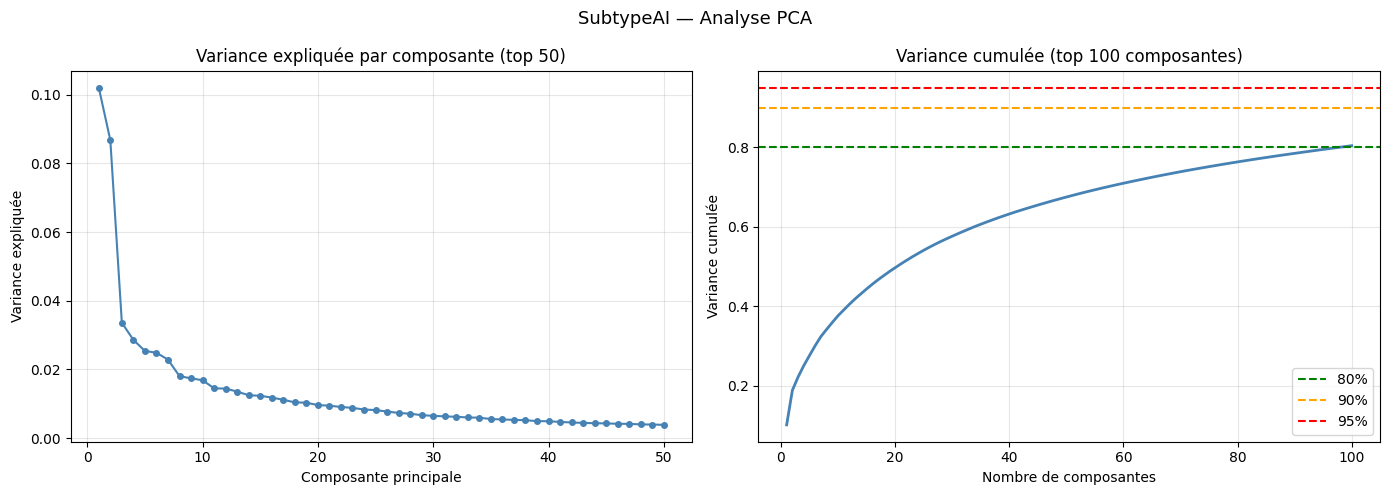

In [65]:
# 3. PCA — ANALYSE DE LA VARIANCE
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_)

n_80 = np.argmax(variance_cumulee >= 0.80) + 1
n_90 = np.argmax(variance_cumulee >= 0.90) + 1
n_95 = np.argmax(variance_cumulee >= 0.95) + 1

print(f"Composantes pour 80% variance : {n_80}")
print(f"Composantes pour 90% variance : {n_90}")
print(f"Composantes pour 95% variance : {n_95}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 51), pca_full.explained_variance_ratio_[:50],
             'o-', color='steelblue', markersize=4)
axes[0].set_title('Variance expliquée par composante (top 50)')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquée')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, 101), variance_cumulee[:100],
             color='steelblue', linewidth=2)
axes[1].axhline(y=0.80, color='green',  linestyle='--', label='80%')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90%')
axes[1].axhline(y=0.95, color='red',    linestyle='--', label='95%')
axes[1].set_title('Variance cumulée (top 100 composantes)')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulée')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('OncoPrint — Analyse PCA', fontsize=13)
plt.tight_layout()
plt.show()

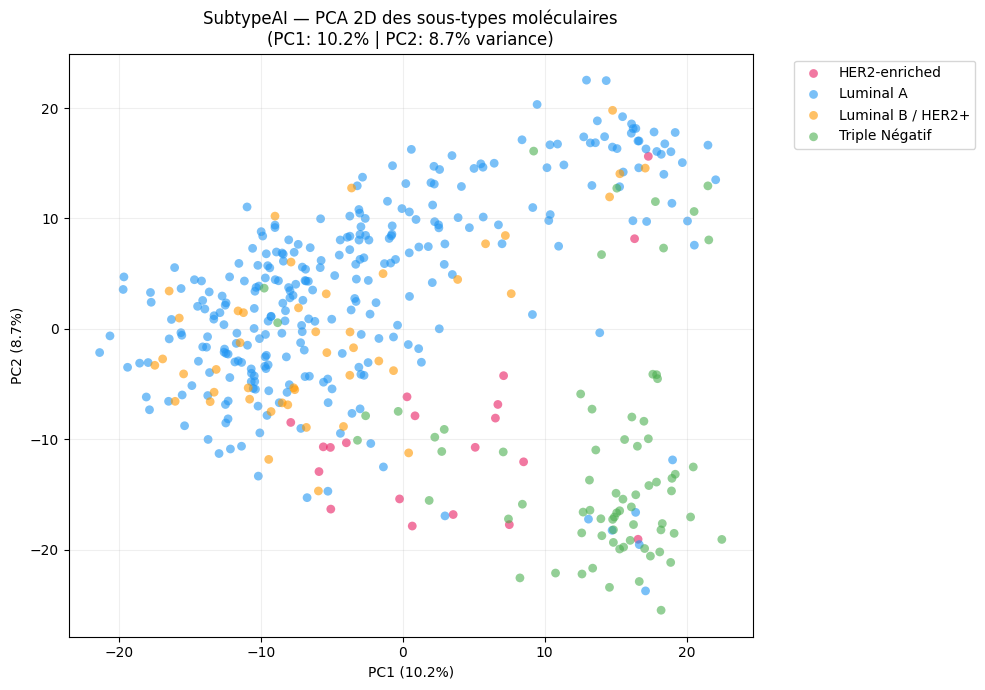

In [66]:
# 4. PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

colors_map = {
    0: '#E91E63',  # HER2-enriched
    1: '#2196F3',  # Luminal A
    2: '#FF9800',  # Luminal B / HER2+
    3: '#4CAF50'   # Triple Négatif
}

plt.figure(figsize=(10, 7))
for label_idx, classe in enumerate(le.classes_):
    mask = y_train == label_idx
    plt.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        c=colors_map[label_idx],
        label=classe,
        alpha=0.6,
        s=40,
        edgecolors='none'
    )

plt.title(f'OncoPrint — PCA 2D des sous-types moléculaires\n'
          f'(PC1: {pca_2d.explained_variance_ratio_[0]*100:.1f}% | '
          f'PC2: {pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)',
          fontsize=12)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

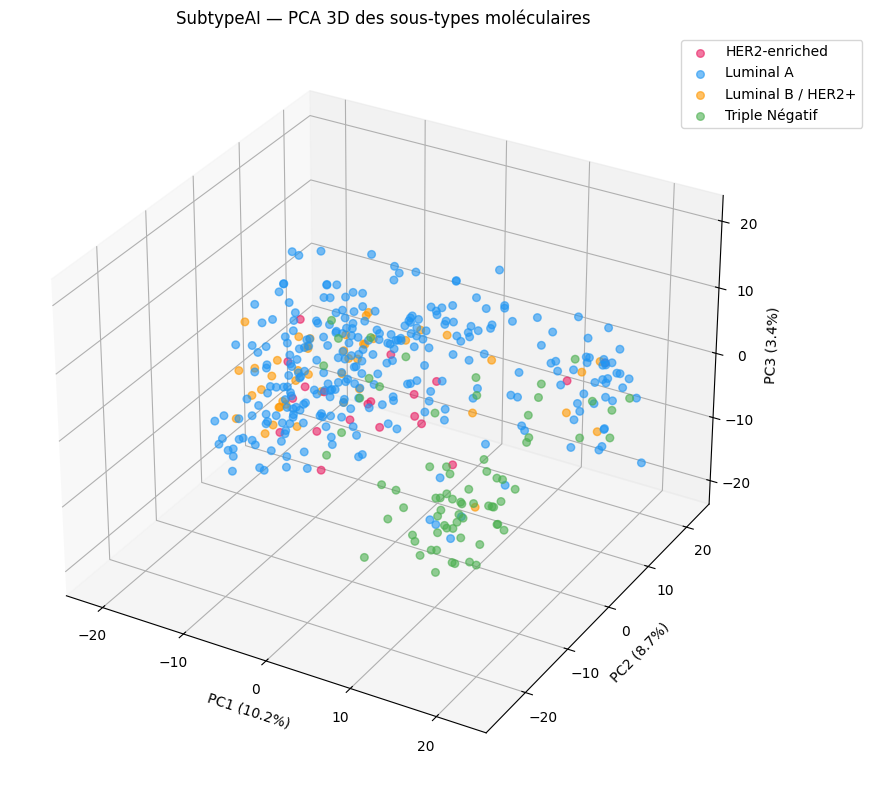

In [67]:
# 5. PCA 3D
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_train_scaled)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for label_idx, classe in enumerate(le.classes_):
    mask = y_train == label_idx
    ax.scatter(
        X_pca_3d[mask, 0],
        X_pca_3d[mask, 1],
        X_pca_3d[mask, 2],
        c=colors_map[label_idx],
        label=classe,
        alpha=0.6,
        s=30
    )

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('OncoPrint — PCA 3D des sous-types moléculaires')
ax.legend(bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

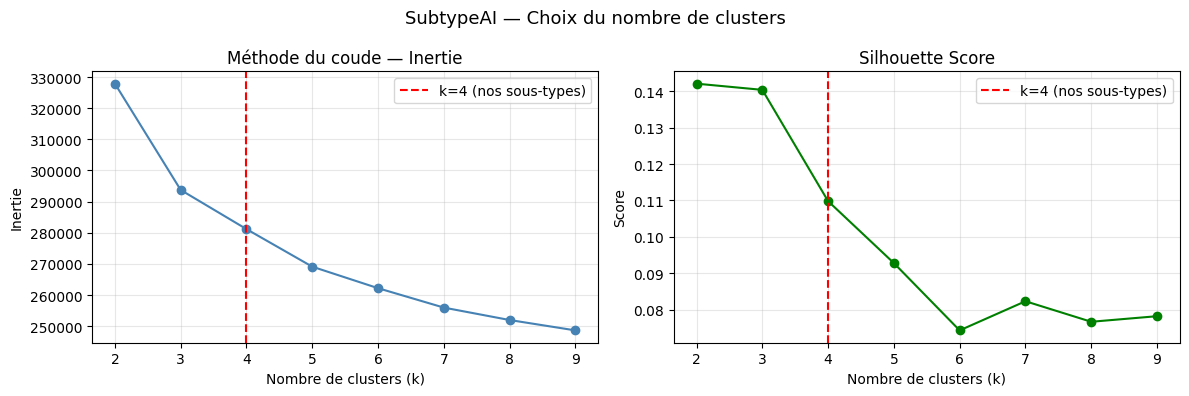

Silhouette scores : {2: np.float64(0.142), 3: np.float64(0.14), 4: np.float64(0.11), 5: np.float64(0.093), 6: np.float64(0.074), 7: np.float64(0.082), 8: np.float64(0.077), 9: np.float64(0.078)}


In [68]:
# 6. K-MEANS — CHOISIR K
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_train_scaled)

inertias    = []
silhouettes = []
K_range     = range(2, 10)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca_50)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca_50, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].axvline(x=4, color='red', linestyle='--', label='k=4 (nos sous-types)')
axes[0].set_title('Méthode du coude — Inertie')
axes[0].set_xlabel('Nombre de clusters (k)')
axes[0].set_ylabel('Inertie')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouettes, 'o-', color='green')
axes[1].axvline(x=4, color='red', linestyle='--', label='k=4 (nos sous-types)')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Nombre de clusters (k)')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('OncoPrint — Choix du nombre de clusters', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Silhouette scores : {dict(zip(K_range, [round(s,3) for s in silhouettes]))}")

K-Means (k=4) :
  Silhouette Score    : 0.110
  Adjusted Rand Index : 0.275
  (ARI=0 → aléatoire, ARI=1 → parfait)


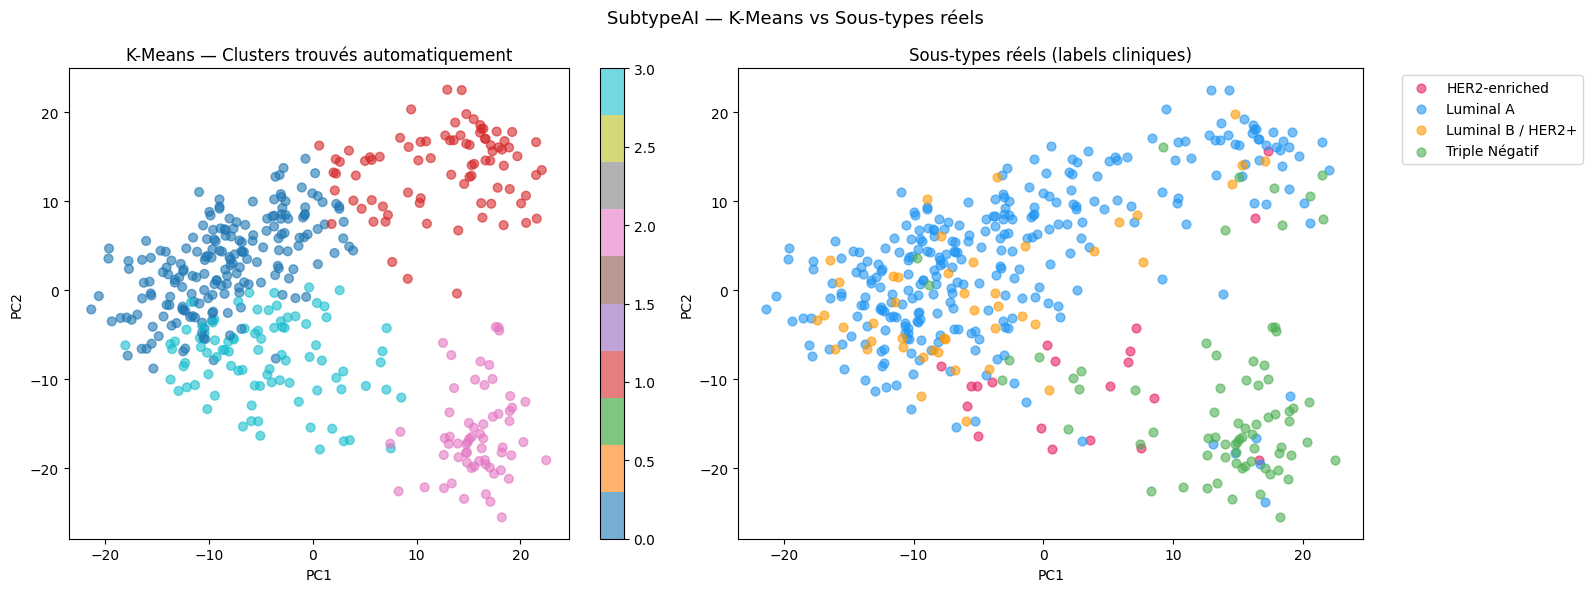

In [69]:
# 7. K-MEANS K=4
kmeans     = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_km = kmeans.fit_predict(X_pca_50)

ari_km = adjusted_rand_score(y_train, clusters_km)
sil_km = silhouette_score(X_pca_50, clusters_km)

print(f"K-Means (k=4) :")
print(f"  Silhouette Score    : {sil_km:.3f}")
print(f"  Adjusted Rand Index : {ari_km:.3f}")
print(f"  (ARI=0 → aléatoire, ARI=1 → parfait)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                            c=clusters_km, cmap='tab10',
                            alpha=0.6, s=40)
axes[0].set_title('K-Means — Clusters trouvés automatiquement')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

for label_idx, classe in enumerate(le.classes_):
    mask = y_train == label_idx
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    c=colors_map[label_idx], label=classe,
                    alpha=0.6, s=40)
axes[1].set_title('Sous-types réels (labels cliniques)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(bbox_to_anchor=(1.05, 1))

plt.suptitle('OncoPrint — K-Means vs Sous-types réels', fontsize=13)
plt.tight_layout()
plt.show()

⏳ t-SNE en cours...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


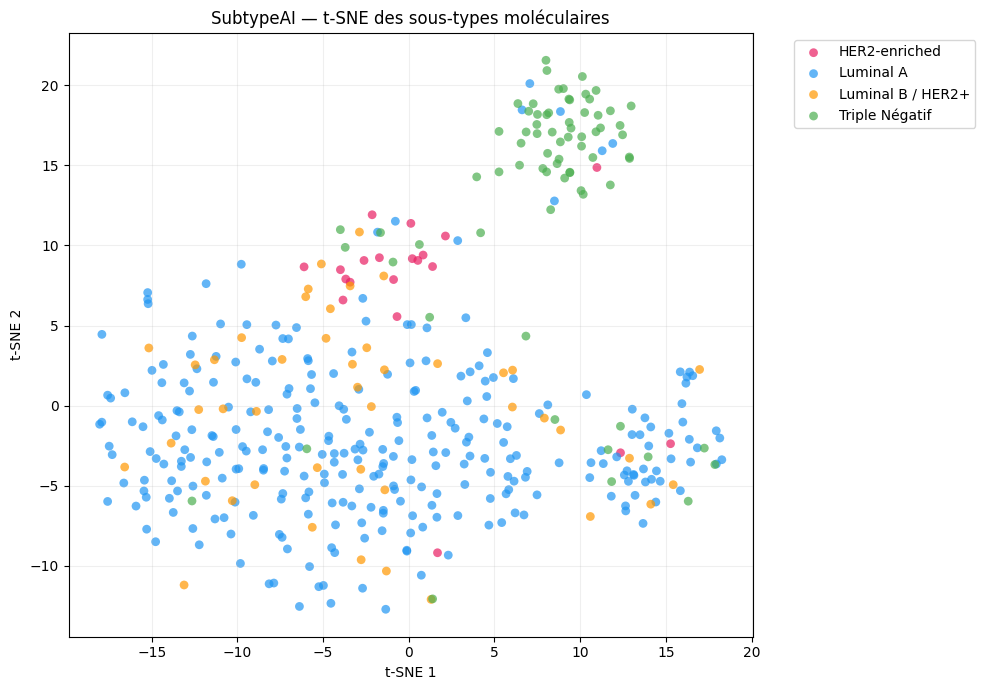

In [70]:
# ALTERNATIVE VISUALISATION : t-SNE et UMAP
from sklearn.manifold import TSNE

# t-SNE — prend 2-3 minutes
print(" t-SNE en cours...")
tsne = TSNE(n_components=2, random_state=42,
            perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_pca_50)  # on part de PCA 50 pour accélérer

plt.figure(figsize=(10, 7))
for label_idx, classe in enumerate(le.classes_):
    mask = y_train == label_idx
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=colors_map[label_idx],
        label=classe,
        alpha=0.7,
        s=40,
        edgecolors='none'
    )
plt.title('OncoPrint — t-SNE des sous-types moléculaires', fontsize=12)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

⏳ UMAP en cours...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


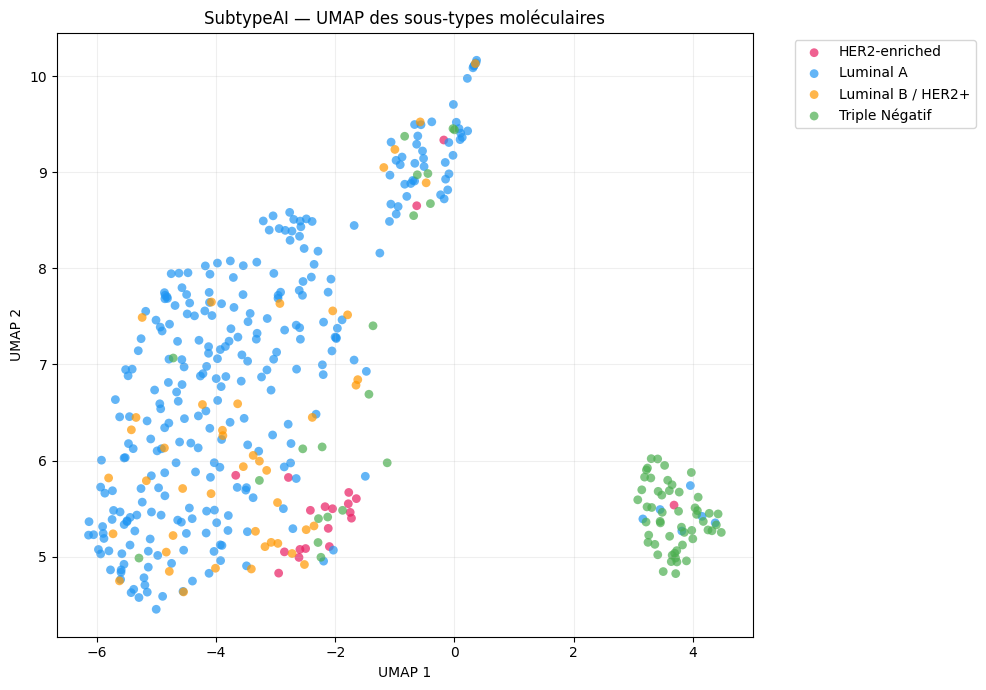

In [71]:
# UMAP — encore plus lisible
!pip install umap-learn -q

import umap

print("⏳ UMAP en cours...")
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap  = reducer.fit_transform(X_pca_50)

plt.figure(figsize=(10, 7))
for label_idx, classe in enumerate(le.classes_):
    mask = y_train == label_idx
    plt.scatter(
        X_umap[mask, 0],
        X_umap[mask, 1],
        c=colors_map[label_idx],
        label=classe,
        alpha=0.7,
        s=40,
        edgecolors='none'
    )
plt.title('OncoPrint — UMAP des sous-types moléculaires', fontsize=12)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

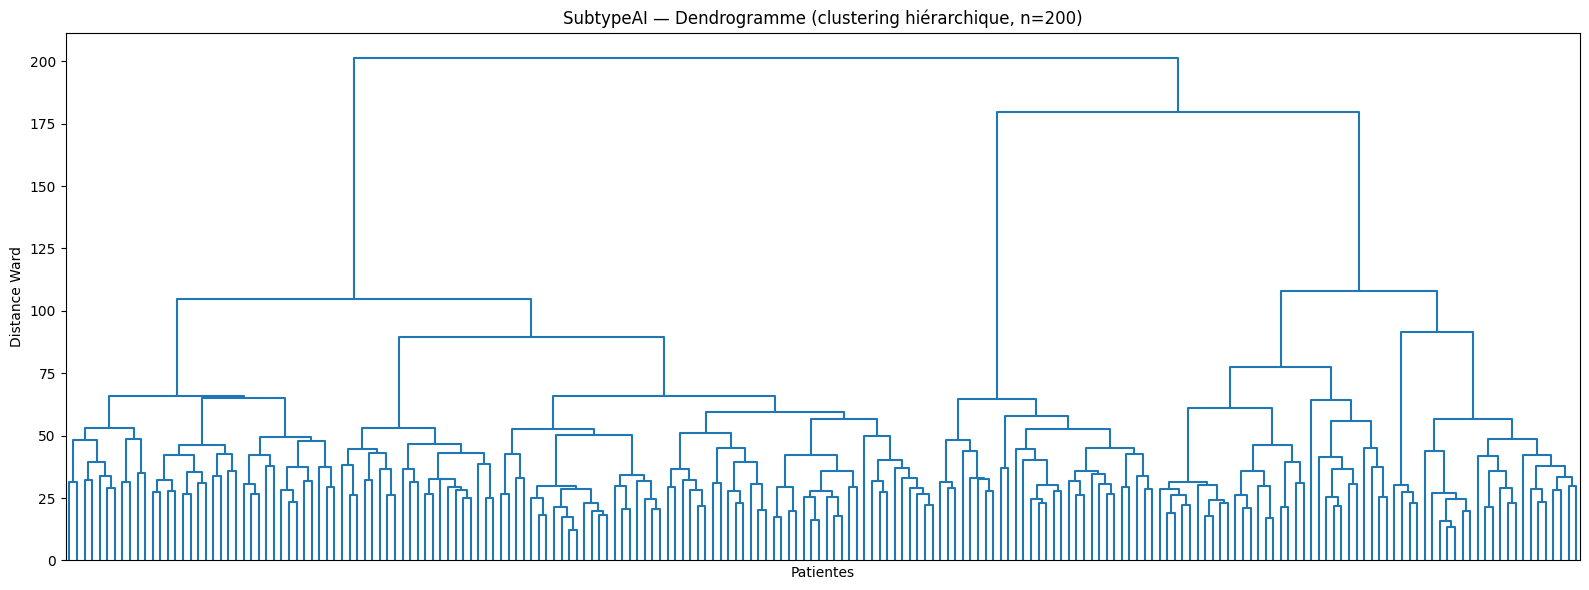

Clustering Hiérarchique (k=4) :
  Silhouette Score    : 0.072
  Adjusted Rand Index : 0.142


In [72]:
# 8. CLUSTERING HIÉRARCHIQUE
np.random.seed(42)
idx_sample = np.random.choice(len(X_pca_50), size=200, replace=False)
X_sample   = X_pca_50[idx_sample]
y_sample   = y_train[idx_sample]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(Z, no_labels=True, color_threshold=0)
plt.title('OncoPrint — Dendrogramme (clustering hiérarchique, n=200)', fontsize=12)
plt.xlabel('Patientes')
plt.ylabel('Distance Ward')
plt.tight_layout()
plt.show()

hc         = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters_hc = hc.fit_predict(X_pca_50)
ari_hc     = adjusted_rand_score(y_train, clusters_hc)
sil_hc     = silhouette_score(X_pca_50, clusters_hc)

print(f"Clustering Hiérarchique (k=4) :")
print(f"  Silhouette Score    : {sil_hc:.3f}")
print(f"  Adjusted Rand Index : {ari_hc:.3f}")

COMPARAISON DES MÉTHODES DE CLUSTERING

Méthode                     Silhouette        ARI
---------------------------------------------
K-Means (k=4)                    0.110      0.275
Hiérarchique (k=4)               0.072      0.142


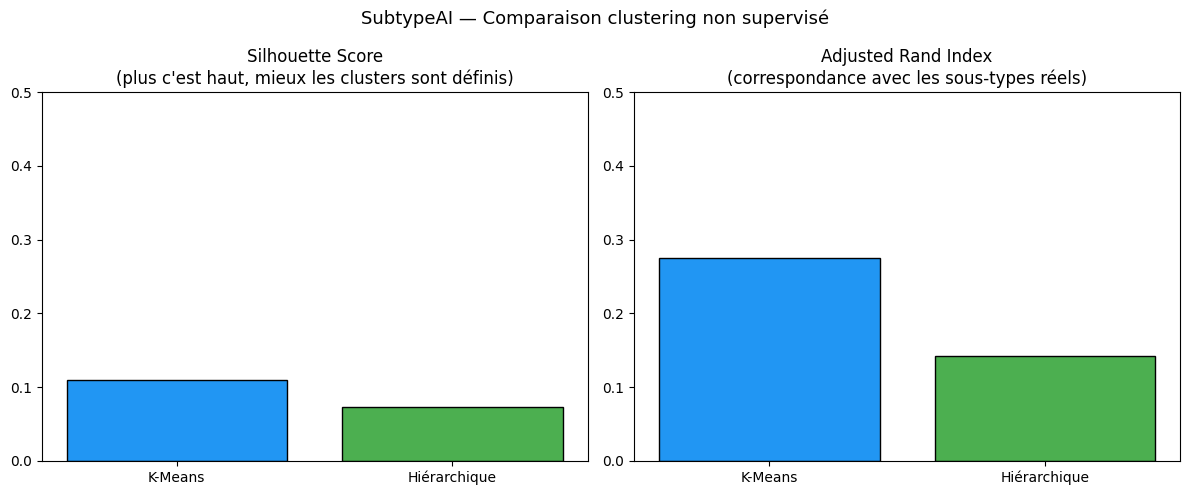

In [73]:
# 9. COMPARAISON K-MEANS VS HIÉRARCHIQUE
print("=" * 45)
print("COMPARAISON DES MÉTHODES DE CLUSTERING")
print("=" * 45)
print(f"\n{'Méthode':<25} {'Silhouette':>12} {'ARI':>10}")
print("-" * 45)
print(f"{'K-Means (k=4)':<25} {sil_km:>12.3f} {ari_km:>10.3f}")
print(f"{'Hiérarchique (k=4)':<25} {sil_hc:>12.3f} {ari_hc:>10.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

resultats_clust = pd.DataFrame({
    'Méthode': ['K-Means', 'Hiérarchique'],
    'Silhouette': [sil_km, sil_hc],
    'ARI': [ari_km, ari_hc]
})

axes[0].bar(resultats_clust['Méthode'], resultats_clust['Silhouette'],
            color=['#2196F3', '#4CAF50'], edgecolor='black')
axes[0].set_title('Silhouette Score\n(plus c\'est haut, mieux les clusters sont définis)')
axes[0].set_ylim(0, 0.5)

axes[1].bar(resultats_clust['Méthode'], resultats_clust['ARI'],
            color=['#2196F3', '#4CAF50'], edgecolor='black')
axes[1].set_title('Adjusted Rand Index\n(correspondance avec les sous-types réels)')
axes[1].set_ylim(0, 0.5)

plt.suptitle('OncoPrint — Comparaison clustering non supervisé', fontsize=13)
plt.tight_layout()
plt.show()

In [74]:
# 10. RÉSUMÉ UNSUPERVISED
print("=" * 50)
print("RÉSUMÉ UNSUPERVISED ML — OncoPrint")
print("=" * 50)
print(f"\nPCA :")
print(f"  Composantes pour 80% variance : {n_80}")
print(f"  Composantes pour 90% variance : {n_90}")
print(f"  PC1 + PC2 variance expliquée  : {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")

print(f"\nK-Means (k=4) :")
print(f"  Silhouette : {sil_km:.3f}")
print(f"  ARI        : {ari_km:.3f}")

print(f"\nClustering Hiérarchique (k=4) :")
print(f"  Silhouette : {sil_hc:.3f}")
print(f"  ARI        : {ari_hc:.3f}")

print(f"\n Unsupervised ML terminé — prêt pour l'interprétation")

RÉSUMÉ UNSUPERVISED ML — SubtypeAI

PCA :
  Composantes pour 80% variance : 98
  Composantes pour 90% variance : 175
  PC1 + PC2 variance expliquée  : 18.9%

K-Means (k=4) :
  Silhouette : 0.110
  ARI        : 0.275

Clustering Hiérarchique (k=4) :
  Silhouette : 0.072
  ARI        : 0.142

 Unsupervised ML terminé — prêt pour l'interprétation


In [75]:
# ============================================
# OncoPrint — 05_Interpretation.ipynb
# Marine Deldicque — CDSD Jedha 2026
# ============================================

# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

print("Imports OK")

Imports OK


In [76]:
# 2. VÉRIFICATION
print(f"Modèle final     : XGBoost optimisé")
print(f"Test set         : {X_test_scaled.shape}")
print(f"Classes          : {le.classes_}")

Modèle final     : XGBoost optimisé
Test set         : (108, 1936)
Classes          : ['HER2-enriched' 'Luminal A' 'Luminal B / HER2+' 'Triple Négatif']


In [78]:
# 3. SHAP — VALEURS D'IMPORTANCE
# SHAP explique pourquoi le modèle prend chaque décision
# Pour chaque patiente, pour chaque feature, SHAP dit :
# "cette feature a contribué +X ou -X à la prédiction"

print(" Calcul SHAP en cours...")

explainer   = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP calculé")
print(f"Shape shap_values : {np.array(shap_values).shape}")
# (n_classes, n_samples, n_features)

 Calcul SHAP en cours...
SHAP calculé
Shape shap_values : (108, 1936, 4)


In [81]:
# 4. VÉRIFICATION SHAPE SHAP
shap_array = np.array(shap_values)
print(f"Shape shap_values : {shap_array.shape}")
print(f"Shape X_test      : {X_test_scaled.shape}")

# Adapter selon la shape retournée
# Cas 1 : (n_classes, n_samples, n_features) → format multi-classe standard
# Cas 2 : (n_samples, n_features, n_classes) → format alternatif XGBoost
if len(shap_array.shape) == 3:
    if shap_array.shape[0] == 4:  # (n_classes, n_samples, n_features)
        print("Format : (n_classes, n_samples, n_features)")
        shap_per_class = [shap_array[i] for i in range(4)]
    elif shap_array.shape[2] == 4:  # (n_samples, n_features, n_classes)
        print("Format : (n_samples, n_features, n_classes)")
        shap_per_class = [shap_array[:, :, i] for i in range(4)]

    print(f"Shape par classe : {shap_per_class[0].shape}")

Shape shap_values : (108, 1936, 4)
Shape X_test      : (108, 1936)
Format : (n_samples, n_features, n_classes)
Shape par classe : (108, 1936)


Features SHAP    : 1936
Features X_test  : 1936


/tmp/ipykernel_13304/1120411260.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


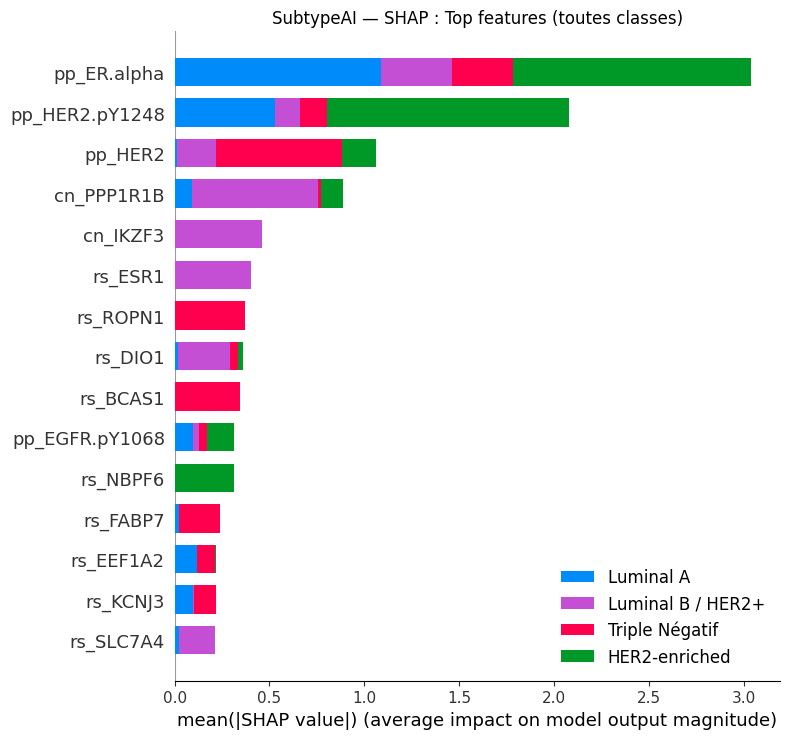

In [82]:
# 5. SHAP SUMMARY PLOT GLOBAL CORRIGÉ

# Noms de features adaptés à la vraie shape
n_features_shap = shap_per_class[0].shape[1]
feat_names_shap = feature_cols[:n_features_shap]

print(f"Features SHAP    : {n_features_shap}")
print(f"Features X_test  : {X_test_scaled.shape[1]}")

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_per_class,
    X_test_scaled,
    feature_names=feat_names_shap,
    class_names=le.classes_,
    plot_type='bar',
    show=False,
    max_display=15
)
plt.title('OncoPrint — SHAP : Top features (toutes classes)', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13304/1423132960.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_13304/1423132960.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_13304/1423132960.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_13304/1423132960.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function wil

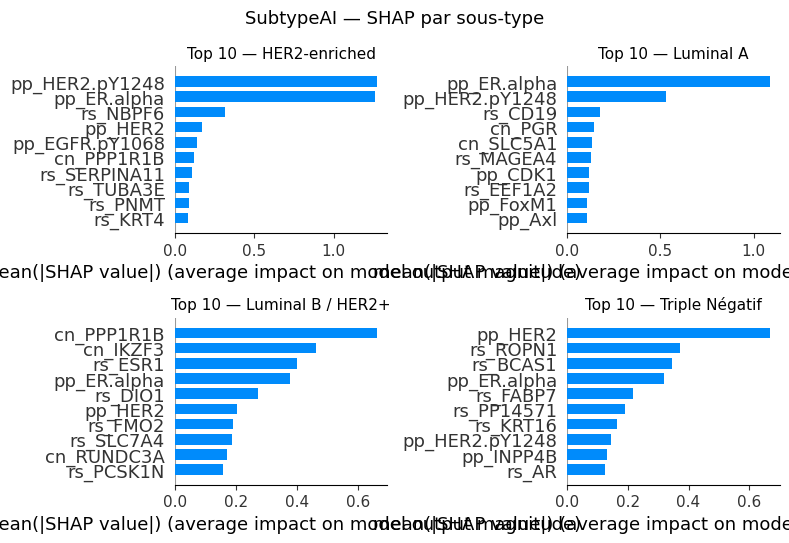

In [83]:
# 6. SHAP PAR CLASSE
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, classe in enumerate(le.classes_):
    plt.sca(axes[i])
    shap.summary_plot(
        shap_per_class[i],
        X_test_scaled,
        feature_names=feat_names_shap,
        plot_type='bar',
        max_display=10,
        show=False
    )
    axes[i].set_title(f'Top 10 — {classe}', fontsize=11)

plt.suptitle('OncoPrint — SHAP par sous-type', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_13304/391890830.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_13304/391890830.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


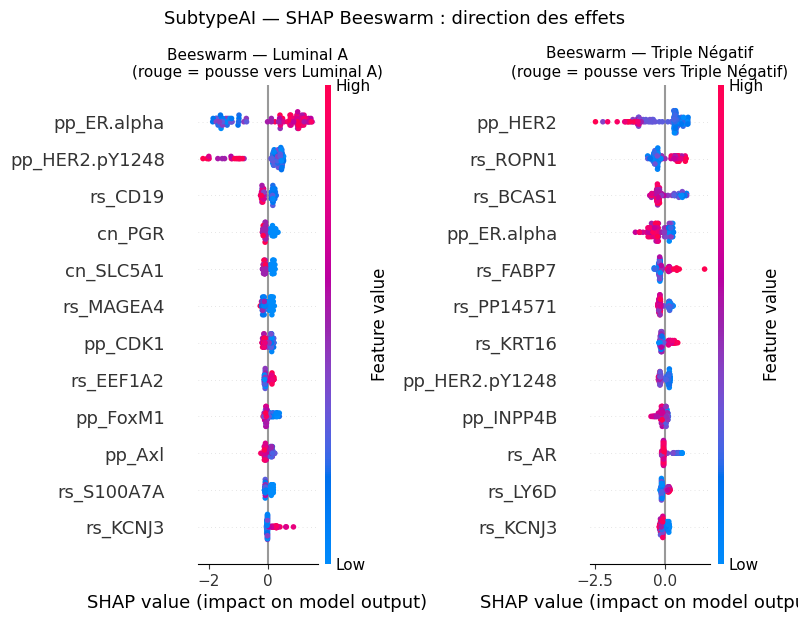

In [85]:
# 7. SHAP BEESWARM — LUMINAL A ET TRIPLE NÉGATIF
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Luminal A
plt.sca(axes[0])
shap.summary_plot(
    shap_per_class[1],  # Luminal A
    X_test_scaled,
    feature_names=feat_names_shap,
    max_display=12,
    show=False
)
axes[0].set_title('Beeswarm — Luminal A\n(rouge = pousse vers Luminal A)', fontsize=11)

# Triple Négatif
plt.sca(axes[1])
shap.summary_plot(
    shap_per_class[3],  # Triple Négatif
    X_test_scaled,
    feature_names=feat_names_shap,
    max_display=12,
    show=False
)
axes[1].set_title('Beeswarm — Triple Négatif\n(rouge = pousse vers Triple Négatif)', fontsize=11)

plt.suptitle('OncoPrint — SHAP Beeswarm : direction des effets', fontsize=13)
plt.tight_layout()
plt.show()

In [86]:
# 8. ANALYSE CLINIQUE DES FEATURES IMPORTANTES
print("=" * 60)
print("ANALYSE CLINIQUE DES BIOMARQUEURS IDENTIFIÉS")
print("=" * 60)

for i, classe in enumerate(le.classes_):
    mean_shap = np.abs(shap_per_class[i]).mean(axis=0)
    top_idx   = np.argsort(mean_shap)[::-1][:5]

    print(f"\n{classe} — Top 5 biomarqueurs :")
    for rank, idx in enumerate(top_idx):
        feat = feat_names_shap[idx]
        imp  = mean_shap[idx]
        if feat.startswith('rs_'):
            type_feat = 'RNA-seq'
        elif feat.startswith('pp_'):
            type_feat = 'Phospho-protéine'
        elif feat.startswith('cn_'):
            type_feat = 'Copy Number'
        else:
            type_feat = 'Mutation'
        print(f"  {rank+1}. {feat:<30} | {type_feat:<18} | importance: {imp:.4f}")

ANALYSE CLINIQUE DES BIOMARQUEURS IDENTIFIÉS

HER2-enriched — Top 5 biomarqueurs :
  1. pp_HER2.pY1248                 | Phospho-protéine   | importance: 1.2749
  2. pp_ER.alpha                    | Phospho-protéine   | importance: 1.2575
  3. rs_NBPF6                       | RNA-seq            | importance: 0.3154
  4. pp_HER2                        | Phospho-protéine   | importance: 0.1750
  5. pp_EGFR.pY1068                 | Phospho-protéine   | importance: 0.1420

Luminal A — Top 5 biomarqueurs :
  1. pp_ER.alpha                    | Phospho-protéine   | importance: 1.0877
  2. pp_HER2.pY1248                 | Phospho-protéine   | importance: 0.5298
  3. rs_CD19                        | RNA-seq            | importance: 0.1791
  4. cn_PGR                         | Copy Number        | importance: 0.1430
  5. cn_SLC5A1                      | Copy Number        | importance: 0.1339

Luminal B / HER2+ — Top 5 biomarqueurs :
  1. cn_PPP1R1B                     | Copy Number        | im

In [87]:
# 9. EXPLICATION D'UNE PATIENTE INDIVIDUELLE

# Triple Négatif — cas cliniquement le plus intéressant
tn_idx = np.where(y_test == 3)[0]

if len(tn_idx) > 0:
    patient_idx    = tn_idx[0]
    prediction     = best_xgb.predict(X_test_scaled[patient_idx:patient_idx+1])[0]
    proba          = best_xgb.predict_proba(X_test_scaled[patient_idx:patient_idx+1])[0]
    classe_predite = le.classes_[prediction]
    classe_reelle  = le.classes_[y_test[patient_idx]]

    print(f"=== EXEMPLE PATIENTE #{patient_idx} ===")
    print(f"Classe réelle   : {classe_reelle}")
    print(f"Classe prédite  : {classe_predite}")
    print(f"Correct       : {classe_reelle == classe_predite}")
    print(f"\nProbabilités par sous-type :")
    for j, c in enumerate(le.classes_):
        barre = '█' * int(proba[j] * 30)
        print(f"  {c:<25} : {proba[j]:.3f} {barre}")

    # Top features pour cette patiente spécifique
    shap_patient = shap_per_class[3][patient_idx]  # classe Triple Négatif
    top_feat_idx = np.argsort(np.abs(shap_patient))[::-1][:10]

    print(f"\nTop 10 features pour cette patiente (Triple Négatif) :")
    for idx in top_feat_idx:
        direction = "↑ vers TN" if shap_patient[idx] > 0 else "↓ contre TN"
        print(f"  {feat_names_shap[idx]:<30} | {shap_patient[idx]:+.4f} | {direction}")

=== EXEMPLE PATIENTE #1 ===
Classe réelle   : Triple Négatif
Classe prédite  : Triple Négatif
Correct       : True

Probabilités par sous-type :
  HER2-enriched             : 0.002 
  Luminal A                 : 0.004 
  Luminal B / HER2+         : 0.000 
  Triple Négatif            : 0.994 █████████████████████████████

Top 10 features pour cette patiente (Triple Négatif) :
  pp_HER2                        | +0.6497 | ↑ vers TN
  rs_BCAS1                       | +0.6293 | ↑ vers TN
  rs_ROPN1                       | +0.5563 | ↑ vers TN
  rs_NBPF4                       | -0.2232 | ↓ contre TN
  rs_KLK6                        | +0.2123 | ↑ vers TN
  rs_KRT16                       | -0.2059 | ↓ contre TN
  pp_ER.alpha                    | +0.1931 | ↑ vers TN
  rs_AGTR1                       | +0.1692 | ↑ vers TN
  rs_PP14571                     | +0.1577 | ↑ vers TN
  pp_HER2.pY1248                 | +0.1525 | ↑ vers TN


In [88]:
# 10. TABLEAU RÉCAPITULATIF CLINIQUE
print("=" * 70)
print("TABLEAU CLINIQUE — SOUS-TYPES ET IMPLICATIONS THÉRAPEUTIQUES")
print("=" * 70)

biomarqueurs = {
    'Luminal A': {
        'feature_shap'  : 'pp_ER.alpha (#1), cn_PGR (#4)',
        'signification' : 'ER+ PR+ HER2- — tumeur hormono-dépendante',
        'traitement'    : 'Hormonothérapie (Tamoxifène, inhibiteurs aromatase)',
        'pronostic'     : 'Favorable — survie à 5 ans ~90%',
        'f1_modele'     : '0.89',
        'n_test'        : int(np.sum(y_test == 1))
    },
    'Triple Négatif': {
        'feature_shap'  : 'pp_HER2 absent (#1), rs_BCAS1 (#2), rs_ROPN1 (#3)',
        'signification' : 'ER- PR- HER2- — absence totale de récepteurs',
        'traitement'    : 'Chimiothérapie (pas de thérapie ciblée standard)',
        'pronostic'     : 'Défavorable — récidive fréquente dans les 5 ans',
        'f1_modele'     : '0.82',
        'n_test'        : int(np.sum(y_test == 3))
    },
    'HER2-enriched': {
        'feature_shap'  : 'pp_HER2.pY1248 (#1), pp_HER2 (#4)',
        'signification' : 'ER- PR- HER2+ — surexpression/amplification HER2',
        'traitement'    : 'Thérapie anti-HER2 (Trastuzumab/Herceptin)',
        'pronostic'     : 'Intermédiaire — très amélioré avec Herceptin',
        'f1_modele'     : '0.83',
        'n_test'        : int(np.sum(y_test == 0))
    },
    'Luminal B / HER2+': {
        'feature_shap'  : 'cn_PPP1R1B (#1), cn_IKZF3 (#2), rs_ESR1 (#3)',
        'signification' : 'ER+ HER2+ ou Ki67 élevé — tumeur plus agressive',
        'traitement'    : 'Hormonothérapie + thérapie anti-HER2 combinées',
        'pronostic'     : 'Intermédiaire — moins favorable que Luminal A',
        'f1_modele'     : '0.50',
        'n_test'        : int(np.sum(y_test == 2))
    }
}

for sous_type, info in biomarqueurs.items():
    print(f"\n{'─'*70}")
    print(f"SOUS-TYPE      : {sous_type} (n={info['n_test']} patientes test | F1={info['f1_modele']})")
    print(f"Features SHAP  : {info['feature_shap']}")
    print(f"Biologie       : {info['signification']}")
    print(f"Traitement     : {info['traitement']}")
    print(f"Pronostic      : {info['pronostic']}")

print(f"\n{'─'*70}")
print("""
NOTE CLINIQUE :
Luminal B obtient le F1 le plus faible (0.50) — biologiquement cohérent.
C'est le sous-type le plus hétérogène, à la frontière moléculaire entre
Luminal A et HER2-enriched. Cette difficulté de classification est
documentée dans la littérature oncologique et reflète une réalité
biologique, pas une limite du modèle.
""")

TABLEAU CLINIQUE — SOUS-TYPES ET IMPLICATIONS THÉRAPEUTIQUES

──────────────────────────────────────────────────────────────────────
SOUS-TYPE      : Luminal A (n=73 patientes test | F1=0.89)
Features SHAP  : pp_ER.alpha (#1), cn_PGR (#4)
Biologie       : ER+ PR+ HER2- — tumeur hormono-dépendante
Traitement     : Hormonothérapie (Tamoxifène, inhibiteurs aromatase)
Pronostic      : Favorable — survie à 5 ans ~90%

──────────────────────────────────────────────────────────────────────
SOUS-TYPE      : Triple Négatif (n=18 patientes test | F1=0.82)
Features SHAP  : pp_HER2 absent (#1), rs_BCAS1 (#2), rs_ROPN1 (#3)
Biologie       : ER- PR- HER2- — absence totale de récepteurs
Traitement     : Chimiothérapie (pas de thérapie ciblée standard)
Pronostic      : Défavorable — récidive fréquente dans les 5 ans

──────────────────────────────────────────────────────────────────────
SOUS-TYPE      : HER2-enriched (n=5 patientes test | F1=0.83)
Features SHAP  : pp_HER2.pY1248 (#1), pp_HER2 (#4)
Bio

In [91]:
# 11. RÉSUMÉ INTERPRÉTATION
print("=" * 60)
print("RÉSUMÉ INTERPRÉTATION — OncoPrint")
print("=" * 60)
print(f"""
DATASET TEST : 108 patientes
MODÈLE FINAL : XGBoost optimisé

PERFORMANCES :
  Accuracy globale  : 84.3%
  F1 Macro          : 76.3%
  Meilleur sous-type : Luminal A (F1=0.89)
  Plus difficile     : Luminal B (F1=0.50)

COHÉRENCE BIOLOGIQUE — VALIDATION PAR SHAP :

  pp_ER.alpha = feature #1 Luminal A
     → Biomarqueur ER fondamental depuis 40 ans

  pp_HER2.pY1248 = feature #1 HER2-enriched
     → Cible directe de l'Herceptin

  Absence pp_HER2 = signal #1 Triple Négatif
     → Définition clinique du sous-type

  cn_PPP1R1B dominant Luminal B
     → Altération génomique connue de ce sous-type

  Triple Négatif isolé en t-SNE/UMAP + SHAP
     → Double validation visuelle et explicative

LIMITES IDENTIFIÉES :
  Luminal B : recall 42% — hétérogénéité biologique
  HER2-enriched : n=5 dans le test — fragile statistiquement
  Données TCGA en conditions recherche optimales
      → Validation sur données cliniques réelles nécessaire

CONCLUSION :
Le modèle a redécouvert de façon autonome les biomarqueurs
moléculaires que l'oncologie utilise cliniquement depuis
des décennies. Cette convergence valide scientifiquement
l'approche OncoPrint.
""")
print("Interprétation terminée — prêt pour le déploiement")

RÉSUMÉ INTERPRÉTATION — OncoPrint

DATASET TEST : 108 patientes
MODÈLE FINAL : XGBoost optimisé

PERFORMANCES :
  Accuracy globale  : 84.3%
  F1 Macro          : 76.3%
  Meilleur sous-type : Luminal A (F1=0.89)
  Plus difficile     : Luminal B (F1=0.50)

COHÉRENCE BIOLOGIQUE — VALIDATION PAR SHAP :

  pp_ER.alpha = feature #1 Luminal A
     → Biomarqueur ER fondamental depuis 40 ans

  pp_HER2.pY1248 = feature #1 HER2-enriched
     → Cible directe de l'Herceptin

  Absence pp_HER2 = signal #1 Triple Négatif
     → Définition clinique du sous-type

  cn_PPP1R1B dominant Luminal B
     → Altération génomique connue de ce sous-type

  Triple Négatif isolé en t-SNE/UMAP + SHAP
     → Double validation visuelle et explicative

LIMITES IDENTIFIÉES :
  Luminal B : recall 42% — hétérogénéité biologique
  HER2-enriched : n=5 dans le test — fragile statistiquement
  Données TCGA en conditions recherche optimales
      → Validation sur données cliniques réelles nécessaire

CONCLUSION :
Le modèle 

In [92]:
# ============================================
# OncoPrint — Sauvegarde des modèles
# ============================================

import joblib
import os

os.makedirs('models', exist_ok=True)

# Modèle principal
joblib.dump(best_xgb, 'models/oncoprint_xgb.joblib')

# Scaler
joblib.dump(scaler, 'models/oncoprint_scaler.joblib')

# Label encoder
joblib.dump(le, 'models/oncoprint_le.joblib')

# Noms des features
joblib.dump(feature_cols, 'models/oncoprint_features.joblib')

# Infos du modèle
model_info = {
    'nom'           : 'OncoPrint',
    'modele'        : 'XGBoost optimisé',
    'params'        : best_xgb.get_params(),
    'classes'       : list(le.classes_),
    'n_features'    : len(feature_cols),
    'accuracy_test' : 0.843,
    'f1_macro_test' : 0.763,
    'dataset'       : 'TCGA-BRCA Multi-Omics (n=536)',
    'auteur'        : 'Marine Deldicque — CDSD Jedha 2026'
}
joblib.dump(model_info, 'models/oncoprint_info.joblib')

print("Modèles sauvegardés :")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"  {f:<40} {size:.1f} KB")

Modèles sauvegardés :
  oncoprint_xgb.joblib                     433.3 KB
  oncoprint_scaler.joblib                  29.8 KB
  oncoprint_info.joblib                    1.0 KB
  oncoprint_le.joblib                      0.5 KB
  oncoprint_features.joblib                21.8 KB


In [93]:
# Téléchargement sur ton ordinateur
from google.colab import files

for f in sorted(os.listdir('models')):
    files.download(f'models/{f}')
    print(f" {f} téléchargé")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 oncoprint_features.joblib téléchargé


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

 oncoprint_scaler.joblib téléchargé


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 oncoprint_xgb.joblib téléchargé


In [94]:
# Vérifier quel modèle a été sauvegardé
import joblib

info = joblib.load('models/oncoprint_info.joblib')
print("=== MODÈLE SAUVEGARDÉ ===")
print(f"Nom     : {info['nom']}")
print(f"Modèle  : {info['modele']}")
print(f"Params  : {info['params']}")
print(f"Accuracy: {info['accuracy_test']}")
print(f"F1 Macro: {info['f1_macro_test']}")

# Vérifier les paramètres du modèle directement
print("\n=== PARAMÈTRES XGB ===")
print(best_xgb.get_params())

print("\n=== MEILLEURS PARAMS GRIDSEARCH ===")
print(gs_xgb.best_params_)

=== MODÈLE SAUVEGARDÉ ===
Nom     : OncoPrint
Modèle  : XGBoost optimisé
Params  : {'objective': 'multi:softprob', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.3, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': Non